# ⚖️ Imbalanced Data & Model Evaluation — Measuring What Matters When the Interesting Class Is Rare

> **What you'll learn:** why accuracy lies on rare events, the full metric zoo (precision, recall, F-beta, specificity, balanced accuracy, MCC, Cohen's κ, ROC-AUC vs PR-AUC, log loss, Brier score, multiclass averaging, regression metrics), choosing decision thresholds from a cost matrix, calibration and why resampling breaks it, class weights, random resampling, SMOTE and its variants, cleaning methods and balanced ensembles — with every resampler inside the training folds — and an honest evaluation protocol: stratified / grouped / time-based splits, nested CV, bootstrap confidence intervals and statistical model comparisons. You'll build PR/ROC curves and SMOTE from scratch and design a cost-based fraud review policy.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [Feature Engineering and Selection](16_Feature_Engineering_and_Selection.ipynb) (leak-free pipelines, selection inside CV) · [Logistic Regression](04_Logistic_Regression.ipynb) (probabilities, log loss, thresholds) · [Scikit-Learn](02_Scikit_Learn.ipynb) (Section 10 gave a first look at `class_weight`, `TunedThresholdClassifierCV` and calibration) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · imbalanced-learn 0.14 · statsmodels 0.15 · pandas 3.0 · numpy 2.5 |
| **Interview relevance** | ⭐⭐⭐ High — "your model is 99% accurate, is it good?", precision vs recall, ROC vs PR, threshold selection, calibration, SMOTE and its leak, "how do you compare two models?", fraud / churn / medical screening design |

## 🤔 What Is Imbalanced Data?

A dataset is **imbalanced** when one class is much rarer than the other: 1 fraudulent card payment in 100, 1 cancer in 50 mammograms, 1 churner in 20 customers. The rare class is usually the one we care about, called the **positive** class.

**Analogy: airport security.** If 1 bag in 10,000 contains something dangerous, a guard who waves *every* bag through is "99.99% accurate" and completely useless. What matters is: of the dangerous bags, how many did we catch (**recall**)? Of the bags we opened, how many were really dangerous (**precision**)? And what does each kind of mistake **cost**?

Three questions structure this notebook:

```
 1. MEASURE  — which metric reflects the real goal?      (confusion matrix, PR-AUC, cost, calibration)
 2. DECIDE   — where do we cut the score into yes / no?  (thresholds from costs, tuned on validation data)
 3. TRAIN    — should we rebalance the training data?    (class weights, resampling, SMOTE, balanced ensembles)
```

**The one rule:** evaluate with metrics and splits that match how the model will be used, and do every data-dependent step (resampling, threshold tuning, calibration) **inside** the training folds.

## 🎯 Why It Matters

- **Most valuable ML problems are imbalanced:** fraud, credit default, churn, medical screening, defect detection, ad clicks, content moderation, security alerts. Getting the evaluation wrong means shipping a model that looks great and does nothing.
- **Metrics drive decisions.** A fraud team with capacity for 500 reviews a day needs precision at the top of the ranking; a cancer screen needs high recall; a bank pricing loans needs calibrated probabilities. The same model can be good for one and bad for another.
- **Resampling is widely misused.** SMOTE before splitting inflates scores dramatically (Section 10 measures it), and resampling silently breaks probability calibration (Section 7). Knowing this separates practitioners from tutorial-followers.
- **In interviews** you'll hear: *"Your model has 99% accuracy — good?"*, *"ROC-AUC or PR-AUC?"*, *"How do you pick the threshold?"*, *"How does SMOTE work, and when does it hurt?"*, *"Are these probabilities trustworthy?"*, *"Is model B really better than model A?"*, *"Design the evaluation for a fraud model."*

## 🃏 Algorithm Card

This notebook teaches *techniques* for imbalanced problems, so the card compares them side by side.

| | Class weights | Threshold tuning | Calibration | Random under / over-sampling | SMOTE family | Cleaning (Tomek, ENN) | Balanced ensembles |
|---|---|---|---|---|---|---|---|
| **Learning type** | Applies to any supervised classifier that accepts weights | Post-processing of any probabilistic / scoring classifier | Post-processing of any probabilistic classifier | Data-level preprocessing for any supervised classifier | Data-level: synthetic minority samples | Data-level: removes ambiguous majority samples | Ensembles that resample per base learner |
| **Tasks** | Binary and multiclass classification | Binary classification decisions | Binary (and multiclass) probability estimates | Classification | Classification (numeric features; SMOTE-NC for mixed) | Classification | Classification |
| **Model / objective** | Weighted loss $\sum_i w_{y_i}\,\ell(y_i, \hat p_i)$, e.g. `"balanced"`: $w_c = n / (K\, n_c)$ | Pick $t$ minimizing expected cost / maximizing a metric; Bayes rule for calibrated $p$: flag if $p > \frac{C_{FP}}{C_{FP}+C_{FN}}$ | Fit a monotone map score → probability: Platt (sigmoid) or isotonic regression | Duplicate minority rows or drop majority rows until a target ratio | New point $x_i + u\,(x_{nn} - x_i)$, $u \sim U(0,1)$, between a minority point and a minority neighbour | Tomek link: mutual nearest neighbours of different classes; ENN: drop points misclassified by their neighbours | Balanced Random Forest: each tree on a balanced bootstrap; EasyEnsemble: AdaBoost on balanced undersamples |
| **Key hyperparameters (typical ranges)** | `class_weight` ("balanced" or a dict; ratio 1–100) | `scoring` (cost / F-beta), `thresholds` (100 grid points), `cv` | `method` ("sigmoid" small data, "isotonic" ≥ ~1,000 calibration rows), `cv` | `sampling_strategy` (minority : majority ratio 0.1–1) | `k_neighbors` (3–10), `sampling_strategy`, `kind` (borderline-1/2) | `n_neighbors` (ENN: 3), `kind_sel` | `n_estimators` (100–500), `sampling_strategy`, `replacement` |
| **Needs feature scaling?** | Only if the base model does | No | No | No | **Yes** (distances between neighbours) | **Yes** (distances) | No (tree based) |
| **Handles missing values / categoricals?** | As the base model | N/A | N/A | Yes (copies / drops rows as they are) | SMOTE: numeric only, no NaN; SMOTE-NC: mixed numeric + categorical | Numeric, no NaN | As random forest / AdaBoost in scikit-learn (NaN supported by trees, categoricals need encoding) |
| **Training & prediction complexity** | Same as base model | CV fits × number of thresholds (cheap scoring) | + CV fits; prediction almost free | Oversampling grows training time; undersampling shrinks it | O(n_min² · d) neighbour search (or tree-based kNN) | O(n² · d) neighbour search | Undersampled trees are fast; prediction as a forest |
| **Interpretability** | Same as base model | High: one explicit number tied to costs | High: reliability diagram | Same as base model | Lower: synthetic training points aren't real people | Same as base model | As random forest |
| **Strengths** | One argument, no data changes, works with strong models | Directly optimizes the business decision; no retraining | Honest probabilities for expected-value decisions and risk scores | Simple; undersampling speeds up huge datasets | Can help weak / high-bias learners with very few positives | Sharpens the boundary; can help kNN-style models | Strong, fast baselines on heavy imbalance |
| **Weaknesses** | Distorts probabilities (needs correction or recalibration) | Needs held-out data; threshold drifts with prevalence | Needs extra data; isotonic can overfit small sets | Oversampling → overfitting duplicates; undersampling throws data away; both distort probabilities | Leaks if done before splitting; noisy synthetic points in overlapping regions; breaks calibration; often no gain for strong models | Can remove informative points; slow on big data | Probabilities skewed toward the minority; less tunable than gradient boosting |
| **Use it when** | You want the model to care more about the rare class during training | You must turn scores into actions with known costs or capacity | Probabilities themselves are used (pricing, risk, expected cost, ranking with budgets) | Huge majority class (undersample for speed) or very weak learners | Weak learners, tiny minority, and CV shows a gain | Noisy class overlap and distance-based models | Quick robust baseline under heavy imbalance |
| **Avoid it when** | You need raw calibrated probabilities and can't correct them | You have no validation data | Probabilities are only used for ranking | Calibrated probabilities are required | Categorical-heavy data (use SMOTE-NC) or strong gradient boosting that already ranks well | Large data or when every positive is precious | You need best-in-class accuracy (tune gradient boosting + threshold instead) |
| **Best libraries** | scikit-learn (`class_weight`, `sample_weight`), XGBoost `scale_pos_weight`, LightGBM `is_unbalance` | scikit-learn `TunedThresholdClassifierCV`, `FixedThresholdClassifier` | scikit-learn `CalibratedClassifierCV`, `CalibrationDisplay` | imbalanced-learn `RandomUnderSampler`, `RandomOverSampler` | imbalanced-learn `SMOTE`, `BorderlineSMOTE`, `ADASYN`, `SMOTENC` | imbalanced-learn `TomekLinks`, `EditedNearestNeighbours`, `SMOTETomek`, `SMOTEENN` | imbalanced-learn `BalancedRandomForestClassifier`, `EasyEnsembleClassifier` |

## ✅ By the End You Can

- [ ] Compute and explain precision, recall, F-beta, specificity, balanced accuracy, MCC, κ, ROC-AUC, PR-AUC, log loss and Brier score, and choose the right one for a problem
- [ ] Turn a cost matrix into a decision threshold, tune it on validation data only, and wrap it with `TunedThresholdClassifierCV` / `FixedThresholdClassifier`
- [ ] Diagnose and fix calibration with reliability diagrams, `CalibratedClassifierCV` and prior correction after resampling
- [ ] Apply class weights, random resampling, SMOTE variants, cleaning methods and balanced ensembles inside an `imblearn` pipeline — and show the leak when you don't
- [ ] Evaluate honestly with stratified / grouped / time-based splits, nested CV, bootstrap confidence intervals, paired comparisons and McNemar's test
- [ ] Implement precision–recall / ROC curves, average precision and SMOTE from scratch, matching scikit-learn and imbalanced-learn

## 📋 Table of Contents

1. [Why Accuracy Lies: The Confusion Matrix](#1.-Why-Accuracy-Lies:-The-Confusion-Matrix-🟢)
2. [The Metric Zoo: Precision, Recall, F-beta, MCC and Friends](#2.-The-Metric-Zoo:-Precision,-Recall,-F-beta,-MCC-and-Friends-🟢)
3. [ROC-AUC vs PR-AUC When Positives Are Rare](#3.-ROC-AUC-vs-PR-AUC-When-Positives-Are-Rare-🟡)
4. [Probability Metrics: Log Loss and Brier Score](#4.-Probability-Metrics:-Log-Loss-and-Brier-Score-🟢)
5. [Multiclass Averaging and Regression Metrics](#5.-Multiclass-Averaging-and-Regression-Metrics-🟡)
6. [Decision Thresholds From a Cost Matrix](#6.-Decision-Thresholds-From-a-Cost-Matrix-🟡)
7. [Calibration and Why Resampling Breaks It](#7.-Calibration-and-Why-Resampling-Breaks-It-🔴)
8. [Class Weights and Random Resampling](#8.-Class-Weights-and-Random-Resampling-🟢)
9. [SMOTE, Its Variants and Cleaning Methods](#9.-SMOTE,-Its-Variants-and-Cleaning-Methods-🟡)
10. [The SMOTE-Before-Splitting Leak](#10.-The-SMOTE-Before-Splitting-Leak-🔴)
11. [Balanced Ensembles and the Honest Verdict](#11.-Balanced-Ensembles-and-the-Honest-Verdict-🔴)
12. [An Honest Evaluation Protocol](#12.-An-Honest-Evaluation-Protocol-🔴)
- [🃏 Algorithm Card](#🃏-Algorithm-Card) · [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-A-Cost-Based-Fraud-Review-Policy) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

**Data (all real; cached in `_outputs/`):**
- **Credit-card fraud** (OpenML 1597, ~70 MB download): 284,807 European card payments from two days in 2013, 492 frauds (0.17%). Features `V1`–`V28` are anonymized PCA components plus `Amount`. **We keep all 492 frauds and a random 49,000 of the legitimate payments**, so the positive rate is about 1% — still heavily imbalanced, but light enough to run many experiments on a laptop. Absolute counts (and precision) would be lower at the true 0.17% prevalence; Section 3 shows exactly how prevalence changes each metric. 25% of these rows are locked away for the mini project.
- **Mammography** (OpenML 310): 11,183 mammogram regions with 6 features, 2.3% malignant.
- **imbalanced-learn benchmark collection** (`imblearn.datasets.fetch_datasets`, a one-time ~230 MB archive): 27 real imbalanced datasets; we use a handful.
- **Adult census income** (OpenML 1590, 24% positive, mixed types), **red wine quality** (OpenML 40691, multiclass with rare grades), **bike sharing** (OpenML 42712, regression), **electricity prices** (OpenML 151, time-ordered) and **Titanic** (OpenML 40945, passengers travelling in groups).

In [1]:
# %pip install -q "scikit-learn>=1.6" "imbalanced-learn>=0.13" "statsmodels>=0.14" "pandas>=2.2" matplotlib

import gc
import sys
import time
import warnings
from pathlib import Path

import imblearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import statsmodels
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.datasets import fetch_datasets
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from imblearn.over_sampling import ADASYN, SMOTE, SMOTENC, BorderlineSMOTE, RandomOverSampler
from imblearn.pipeline import make_pipeline as make_imb_pipeline
from imblearn.under_sampling import EditedNearestNeighbours, RandomUnderSampler, TomekLinks
from scipy import stats
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor, RandomForestClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    fbeta_score,
    log_loss,
    make_scorer,
    matthews_corrcoef,
    mean_absolute_error,
    mean_absolute_percentage_error,
    metric_at_thresholds,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    root_mean_squared_error,
)
from sklearn.model_selection import (
    FixedThresholdClassifier,
    GridSearchCV,
    KFold,
    RepeatedStratifiedKFold,
    StratifiedGroupKFold,
    StratifiedKFold,
    TimeSeriesSplit,
    TunedThresholdClassifierCV,
    cross_val_predict,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from statsmodels.stats.contingency_tables import mcnemar

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | imbalanced-learn {imblearn.__version__} | "
      f"statsmodels {statsmodels.__version__} | pandas {pd.__version__} | numpy {np.__version__} | scipy {scipy.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 160)
OUTPUT_DIR = Path("_outputs")              # files we write go here (ignored by git)
DATA_HOME = OUTPUT_DIR / "sklearn_data"    # OpenML cache
IMBLEARN_HOME = OUTPUT_DIR / "imblearn_data"
DATA_HOME.mkdir(parents=True, exist_ok=True)


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (bool, np.bool_, str, dict, set)):
        ok = got == expected
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | scikit-learn 1.9.1 | imbalanced-learn 0.14.2 | statsmodels 0.15.0 | pandas 3.0.5 | numpy 2.5.3 | scipy 1.18.1


In [2]:
def openml(**kwargs):
    return fetch_openml(as_frame=True, data_home=DATA_HOME, **kwargs)


creditcard = openml(data_id=1597).frame
is_fraud = (creditcard["Class"] == "1").astype(int).to_numpy()
keep = np.sort(np.r_[np.flatnonzero(is_fraud == 1), rng.choice(np.flatnonzero(is_fraud == 0), 49_000, replace=False)])
fraud_X = creditcard.drop(columns="Class").iloc[keep].reset_index(drop=True)
fraud_y = is_fraud[keep]
print(f"credit-card fraud: full data {len(creditcard):,} rows, fraud rate {is_fraud.mean():.3%} → "
      f"our sample {len(fraud_X):,} rows ({fraud_y.sum()} frauds, rate {fraud_y.mean():.2%})")
del creditcard, is_fraud
gc.collect()

fraud_X_dev, fraud_X_test, fraud_y_dev, fraud_y_test = train_test_split(fraud_X, fraud_y, test_size=0.25, stratify=fraud_y, random_state=SEED)
print(f"development rows {len(fraud_X_dev):,} ({fraud_y_dev.sum()} frauds) | locked test rows {len(fraud_X_test):,} ({fraud_y_test.sum()} frauds)")

mammo = openml(data_id=310)
mammo_X = mammo.data.to_numpy()
mammo_y = (mammo.target == "1").astype(int).to_numpy()
print(f"mammography: {mammo_X.shape}, malignant rate {mammo_y.mean():.2%}")

dev_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
mammo_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

credit-card fraud: full data 284,807 rows, fraud rate 0.173% → our sample 49,492 rows (492 frauds, rate 0.99%)
development rows 37,119 (369 frauds) | locked test rows 12,373 (123 frauds)
mammography: (11183, 6), malignant rate 2.32%


## 1. Why Accuracy Lies: The Confusion Matrix 🟢

For a binary problem every prediction lands in one of four cells:

```
                       predicted legit (0)     predicted fraud (1)
  actual legit (0)     TN  true negative       FP  false positive  ("false alarm")
  actual fraud (1)     FN  false negative      TP  true positive   ("caught")
                       ("missed")
```

**Accuracy** = (TP + TN) / everything. With 1% fraud, a model that *never* flags anything is 99% accurate. Let's compare that "model" with a real logistic regression, using **out-of-fold** predictions: `cross_val_predict` gives every development row a prediction from a model that didn't train on it.

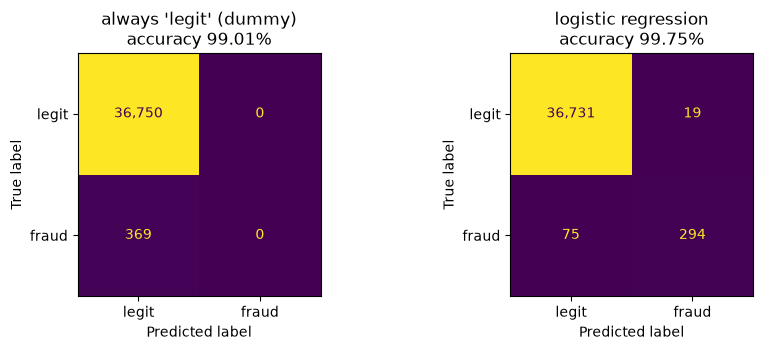

logistic regression at threshold 0.5: caught 294 of 369 frauds (recall 79.7%), 19 false alarms, 93.9% of alarms are real fraud (precision)
the dummy has accuracy 99.01% and catches 0 frauds — accuracy can't tell them apart


In [3]:
lr_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000))
dev_scores = {
    "always 'legit' (dummy)": cross_val_predict(DummyClassifier(strategy="most_frequent"), fraud_X_dev, fraud_y_dev, cv=dev_cv, method="predict_proba")[:, 1],
    "logistic regression": cross_val_predict(lr_pipe, fraud_X_dev, fraud_y_dev, cv=dev_cv, method="predict_proba")[:, 1],
}
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, (name, scores) in zip(axes, dev_scores.items()):
    predictions = (scores >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(fraud_y_dev, predictions, display_labels=["legit", "fraud"], ax=ax, colorbar=False, values_format=",")
    ax.set_title(f"{name}\naccuracy {accuracy_score(fraud_y_dev, predictions):.2%}")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(fraud_y_dev, (dev_scores["logistic regression"] >= 0.5).astype(int)).ravel()
print(f"logistic regression at threshold 0.5: caught {tp} of {tp + fn} frauds (recall {tp / (tp + fn):.1%}), "
      f"{fp} false alarms, {tp / (tp + fp):.1%} of alarms are real fraud (precision)")
print(f"the dummy has accuracy {accuracy_score(fraud_y_dev, np.zeros_like(fraud_y_dev)):.2%} and catches 0 frauds — accuracy can't tell them apart")

### ✍️ Your Turn

A screening model produced TP = 40, FP = 60, FN = 10, TN = 9,890. Compute **precision**, **recall** and **accuracy** and store them as a list `[precision, recall, accuracy]` in `screen_metrics`.

In [4]:
TP, FP, FN, TN = 40, 60, 10, 9_890
screen_metrics = None  # TODO: [precision, recall, accuracy]
check("screen_metrics", screen_metrics, [0.4, 0.8, 0.993], hint="precision = TP/(TP+FP); recall = TP/(TP+FN); accuracy = (TP+TN)/total")

⏳ screen_metrics: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
TP, FP, FN, TN = 40, 60, 10, 9_890
screen_metrics = [TP / (TP + FP), TP / (TP + FN), (TP + TN) / (TP + FP + FN + TN)]
check("screen_metrics", screen_metrics, [0.4, 0.8, 0.993])
```

99.3% accuracy sounds excellent, yet 6 in 10 alarms are false and 1 in 5 positives is missed. Always look at the confusion matrix.
</details>

> 💡 **Interview angle:** "Your fraud model is 99% accurate. Is it good?" — impossible to say: with 1% fraud, predicting "never fraud" is also 99% accurate. Ask for the confusion matrix, recall and precision on the fraud class, the cost of each error type, and compare against the trivial baseline.

## 2. The Metric Zoo: Precision, Recall, F-beta, MCC and Friends 🟢

| Metric | Formula | Question it answers | Watch out |
|---|---|---|---|
| **Precision** (PPV) | TP / (TP + FP) | When we raise an alarm, how often is it right? | depends on prevalence |
| **Recall** (sensitivity, TPR) | TP / (TP + FN) | Of all real positives, how many did we catch? | ignores false alarms |
| **Specificity** (TNR) | TN / (TN + FP) | Of all negatives, how many did we leave alone? | near 1 whenever negatives dominate |
| **F1** | 2PR / (P + R) | balance of precision and recall (harmonic mean) | ignores TN; equal weight to P and R |
| **F-beta** | $(1+\beta^2)\frac{PR}{\beta^2 P + R}$ | β > 1 favours recall (F2 for screening), β < 1 favours precision (F0.5) | still one threshold |
| **Balanced accuracy** | (recall + specificity) / 2 | accuracy where both classes count equally | a dummy scores 0.5 |
| **MCC** | $\frac{TP\cdot TN - FP\cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$ | correlation between truth and prediction, −1 to +1 | uses all four cells: robust summary |
| **Cohen's κ** | $(p_o - p_e)/(1 - p_e)$ | agreement beyond what chance (class frequencies) would give | also used for human annotators |
| **G-mean** | $\sqrt{\text{recall}\cdot\text{specificity}}$ | both classes' hit rates together | popular in imbalance papers |

All of these need **hard predictions**, so they depend on the threshold. Let's compute them on out-of-fold predictions (threshold 0.5) for four models.

In [5]:
dev_scores["logistic regression, class_weight='balanced'"] = cross_val_predict(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, class_weight="balanced")),
    fraud_X_dev, fraud_y_dev, cv=dev_cv, method="predict_proba")[:, 1]
dev_scores["HistGradientBoosting"] = cross_val_predict(
    HistGradientBoostingClassifier(random_state=SEED), fraud_X_dev, fraud_y_dev, cv=dev_cv, method="predict_proba")[:, 1]


def threshold_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    recall, specificity = tp / (tp + fn), tn / (tn + fp)
    return {"accuracy": accuracy_score(y_true, y_pred), "precision": precision_score(y_true, y_pred, zero_division=0.0),
            "recall": recall, "specificity": specificity, "F1": f1_score(y_true, y_pred, zero_division=0.0),
            "F2": fbeta_score(y_true, y_pred, beta=2, zero_division=0.0), "balanced accuracy": balanced_accuracy_score(y_true, y_pred),
            "MCC": matthews_corrcoef(y_true, y_pred), "Cohen's κ": cohen_kappa_score(y_true, y_pred), "G-mean": np.sqrt(recall * specificity),
            "alarms": tp + fp}


zoo = pd.DataFrame({name: threshold_metrics(fraud_y_dev, (scores >= 0.5).astype(int)) for name, scores in dev_scores.items()}).T
print(zoo.round(3).to_string())
print(f"\nhighest accuracy: {zoo['accuracy'].idxmax()} | highest recall: {zoo['recall'].idxmax()} | highest MCC: {zoo['MCC'].idxmax()} | "
      f"highest balanced accuracy: {zoo['balanced accuracy'].idxmax()}")

                                              accuracy  precision  recall  specificity     F1     F2  balanced accuracy    MCC  Cohen's κ  G-mean  alarms
always 'legit' (dummy)                           0.990      0.000   0.000        1.000  0.000  0.000              0.500  0.000      0.000   0.000     0.0
logistic regression                              0.997      0.939   0.797        0.999  0.862  0.822              0.898  0.864      0.861   0.892   313.0
logistic regression, class_weight='balanced'     0.976      0.286   0.916        0.977  0.436  0.636              0.946  0.504      0.427   0.946  1183.0
HistGradientBoosting                             0.998      0.975   0.846        1.000  0.906  0.869              0.923  0.907      0.905   0.919   320.0

highest accuracy: HistGradientBoosting | highest recall: logistic regression, class_weight='balanced' | highest MCC: HistGradientBoosting | highest balanced accuracy: logistic regression, class_weight='balanced'


Read the table row by row: the dummy's accuracy is within about one point of the best model although it catches nothing, and its specificity is perfect; recall, F1, MCC, κ and balanced accuracy all expose it. The class-weighted model has the best recall and balanced accuracy but raises many more alarms, so its precision, F1 and MCC collapse. **Balanced accuracy and G-mean reward recall on the rare class regardless of how many false alarms that costs**, while F1 and MCC punish them. Which one is "right" depends on what a false alarm costs (Section 6).

### ✍️ Your Turn

Compute the **Matthews correlation coefficient** by hand for TP = 40, FP = 60, FN = 10, TN = 9,890 and store it in `mcc_by_hand`.

In [6]:
TP, FP, FN, TN = 40, 60, 10, 9_890
mcc_by_hand = None  # TODO: your code here
check("mcc_by_hand", mcc_by_hand, matthews_corrcoef([1] * 40 + [0] * 60 + [1] * 10 + [0] * 9_890, [1] * 40 + [1] * 60 + [0] * 10 + [0] * 9_890),
      hint="(TP*TN - FP*FN) / sqrt((TP+FP)*(TP+FN)*(TN+FP)*(TN+FN))")

⏳ mcc_by_hand: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
TP, FP, FN, TN = 40, 60, 10, 9_890
mcc_by_hand = (TP * TN - FP * FN) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
check("mcc_by_hand", mcc_by_hand, matthews_corrcoef([1] * 40 + [0] * 60 + [1] * 10 + [0] * 9_890, [1] * 40 + [1] * 60 + [0] * 10 + [0] * 9_890))
```

About 0.56: a clearly useful model, but far from the 0.993 accuracy suggests. MCC is symmetric (swapping which class is "positive" gives the same value), which F1 isn't.
</details>

> 💡 **Interview angle:** "F1 or MCC?" — F1 ignores true negatives and depends on which class you call positive; MCC uses all four cells and is only high when the model does well on both classes (Chicco & Jurman argue it's the safer single number). But for business decisions, neither replaces an explicit cost or a precision/recall target.

## 3. ROC-AUC vs PR-AUC When Positives Are Rare 🟡

Threshold-free metrics look at the **ranking** of scores:

- The **ROC curve** plots recall (TPR) against the false positive rate FPR = FP / (FP + TN) as the threshold moves. **ROC-AUC** = probability that a random positive gets a higher score than a random negative. Random = 0.5.
- The **precision–recall (PR) curve** plots precision against recall. Its summary, **average precision (AP)** $= \sum_n (R_n - R_{n-1})\,P_n$, is often called PR-AUC. **Random = the positive rate** (1% here), not 0.5.

**Why PR is the right lens at 1% positives:** FPR divides by the huge number of negatives, so thousands of false alarms still look like a tiny FPR and the ROC curve hugs the top-left corner. Precision divides by the number of *alarms*, so those false alarms are fully visible (Saito & Rehmsmeier, 2015).

                      ROC-AUC  average precision (PR-AUC)
logistic regression    0.9830                      0.8747
HistGradientBoosting   0.9648                      0.8887
ROC-AUC prefers logistic regression, average precision prefers HistGradientBoosting — the two metrics disagree!


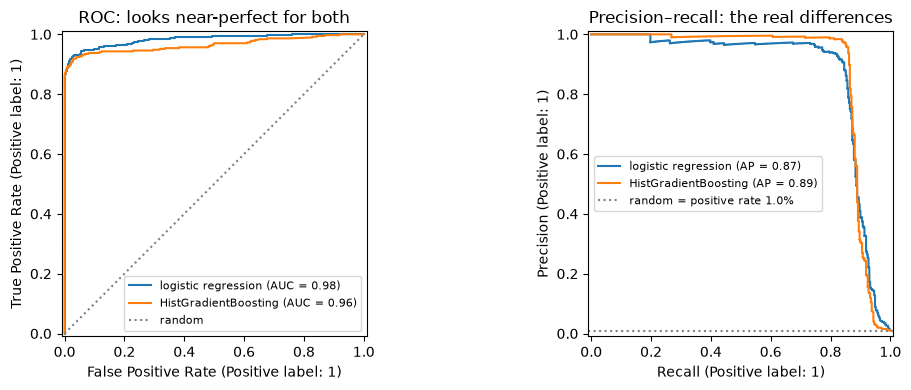

               model  recall target  precision  false-positive rate  false alarms  false alarms per caught fraud
 logistic regression           0.80     0.9397               0.0005            19                         0.0642
 logistic regression           0.85     0.8796               0.0012            43                         0.1369
 logistic regression           0.90     0.3881               0.0143           525                         1.5766
 logistic regression           0.95     0.0892               0.0976          3585                        10.2137
HistGradientBoosting           0.80     0.9867               0.0001             4                         0.0135
HistGradientBoosting           0.85     0.9721               0.0002             9                         0.0287
HistGradientBoosting           0.90     0.3063               0.0205           754                         2.2643
HistGradientBoosting           0.95     0.0291               0.3183         11698               

In [7]:
curve_models = ["logistic regression", "HistGradientBoosting"]
ranking = pd.DataFrame({name: {"ROC-AUC": roc_auc_score(fraud_y_dev, dev_scores[name]), "average precision (PR-AUC)": average_precision_score(fraud_y_dev, dev_scores[name])}
                        for name in curve_models}).T
print(ranking.round(4))
print(f"ROC-AUC prefers {ranking['ROC-AUC'].idxmax()}, average precision prefers {ranking['average precision (PR-AUC)'].idxmax()}"
      + (" — the two metrics disagree!" if ranking['ROC-AUC'].idxmax() != ranking['average precision (PR-AUC)'].idxmax() else ""))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name in curve_models:
    RocCurveDisplay.from_predictions(fraud_y_dev, dev_scores[name], name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(fraud_y_dev, dev_scores[name], name=name, ax=axes[1])
axes[0].plot([0, 1], [0, 1], ls=":", color="gray", label="random")
axes[1].axhline(fraud_y_dev.mean(), ls=":", color="gray", label=f"random = positive rate {fraud_y_dev.mean():.1%}")
axes[0].set_title("ROC: looks near-perfect for both")
axes[1].set_title("Precision–recall: the real differences")
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

recall_rows = []
for name in curve_models:
    precision, recall, thresholds = precision_recall_curve(fraud_y_dev, dev_scores[name])
    for target in [0.80, 0.85, 0.90, 0.95]:
        idx = np.flatnonzero(recall[:-1] >= target)[-1]                  # the highest threshold that still reaches the target recall
        flagged = dev_scores[name] >= thresholds[idx]
        false_alarms = int((flagged & (fraud_y_dev == 0)).sum())
        recall_rows.append({"model": name, "recall target": target, "precision": precision[idx],
                            "false-positive rate": false_alarms / (fraud_y_dev == 0).sum(), "false alarms": false_alarms,
                            "false alarms per caught fraud": false_alarms / flagged[fraud_y_dev == 1].sum()})
recall_table = pd.DataFrame(recall_rows)
print(recall_table.round(4).to_string(index=False))
lr_90 = recall_table.query("model == 'logistic regression' and `recall target` == 0.90").iloc[0]
print(f"\nlogistic regression at 90% recall: a false-positive rate of just {lr_90['false-positive rate']:.2%} — "
      f"yet {int(lr_90['false alarms']):,} false alarms, {lr_90['false alarms per caught fraud']:.1f} per caught fraud (precision {lr_90['precision']:.1%})")

Up to about 85% recall both models are nearly clean. Chasing the last frauds gets expensive fast: at 90% recall the false-positive rate is still only one or two percent (a point high up on the ROC curve), while precision has already collapsed to about a third and false alarms outnumber caught frauds. The PR curve shows that cost; the ROC curve hides it.

**Prevalence experiment.** Keep the same logistic-regression scores, but randomly drop negatives so the positive rate becomes 1%, 5%, 20% or 50% (a controlled manipulation of real predictions). ROC-AUC doesn't care about the class ratio; precision and AP change a lot. That's why a model's precision in production depends on the real fraud rate, and why you must evaluate at the **deployment prevalence**.

In [8]:
positives = np.flatnonzero(fraud_y_dev == 1)
negatives = np.flatnonzero(fraud_y_dev == 0)
prevalence_rows = []
lr_scores = dev_scores["logistic regression"]
for target_rate in [0.01, 0.05, 0.20, 0.50]:
    n_neg = min(len(negatives), int(len(positives) * (1 - target_rate) / target_rate))
    rows = np.r_[positives, rng.choice(negatives, n_neg, replace=False)]
    prevalence_rows.append({"positive rate": fraud_y_dev[rows].mean(), "rows": len(rows),
                            "ROC-AUC": roc_auc_score(fraud_y_dev[rows], lr_scores[rows]),
                            "average precision": average_precision_score(fraud_y_dev[rows], lr_scores[rows]),
                            "precision at threshold 0.5": precision_score(fraud_y_dev[rows], lr_scores[rows] >= 0.5)})
print(pd.DataFrame(prevalence_rows).round(4).to_string(index=False))

 positive rate  rows  ROC-AUC  average precision  precision at threshold 0.5
        0.0100 36900   0.9830             0.8748                      0.9393
        0.0500  7380   0.9832             0.9333                      0.9899
        0.2001  1844   0.9834             0.9674                      1.0000
        0.5000   738   0.9809             0.9850                      1.0000


### ✍️ Your Turn

A classifier that assigns **random** scores has an expected average precision equal to the positive rate. What is that baseline for our development set? Store it in `random_ap_baseline`.

In [9]:
random_ap_baseline = None  # TODO: your code here
check("random_ap_baseline", random_ap_baseline, fraud_y_dev.sum() / len(fraud_y_dev), hint="fraud_y_dev.mean()")

⏳ random_ap_baseline: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
random_ap_baseline = fraud_y_dev.mean()
check("random_ap_baseline", random_ap_baseline, fraud_y_dev.sum() / len(fraud_y_dev))
```

About 0.01. So an AP of 0.5 is 50× better than random here, while a ROC-AUC of 0.5 is exactly random. Always report the baseline next to AP.
</details>

> 💡 **Interview angle:** "ROC-AUC or PR-AUC for a 1%-positive problem?" — PR-AUC / average precision: it focuses on the positive class and its baseline is the prevalence, while ROC-AUC's false-positive rate is diluted by the mass of negatives and can rank models differently. ROC-AUC is prevalence-invariant (useful when comparing across populations); precision is not, so evaluate at deployment prevalence.

## 4. Probability Metrics: Log Loss and Brier Score 🟢

When the **probabilities themselves** are used (expected-cost decisions, pricing, risk scores), judge them directly:

$$\text{log loss} = -\frac1n\sum_i \big[y_i \log p_i + (1-y_i)\log(1-p_i)\big], \qquad \text{Brier} = \frac1n\sum_i (p_i - y_i)^2$$

Both are **proper scoring rules**: they are minimized by reporting your true belief, so they reward calibrated *and* sharp predictions. Log loss punishes confident mistakes brutally (a fraud given p = 0.001 costs $-\log 0.001 \approx 6.9$); the Brier score is bounded between 0 and 1.

On rare events both look tiny even for a useless model, so compare with the **constant baseline** that always predicts the positive rate. The **D² Brier score** (`d2_brier_score`, new in scikit-learn 1.9) = 1 − Brier / Brier(baseline): 0 = no better than the base rate, 1 = perfect.

In [10]:
from sklearn.metrics import d2_brier_score

prevalence_dev = fraud_y_dev.mean()
probability_scores = {"constant = positive rate": np.full(len(fraud_y_dev), prevalence_dev),
                      **{name: dev_scores[name] for name in ["logistic regression", "logistic regression, class_weight='balanced'", "HistGradientBoosting"]}}
probability_table = pd.DataFrame({
    name: {"log loss": log_loss(fraud_y_dev, p), "Brier": brier_score_loss(fraud_y_dev, p), "D² Brier": d2_brier_score(fraud_y_dev, p),
           "mean predicted P(fraud)": p.mean(), "actual fraud rate": prevalence_dev}
    for name, p in probability_scores.items()}).T
print(probability_table.round(5).to_string())
worst = np.argmax(np.where(fraud_y_dev == 1, -np.log(np.clip(dev_scores["HistGradientBoosting"], 1e-15, 1)), 0))
print(f"\nclass_weight='balanced' predicts an average P(fraud) of {probability_table.iloc[2]['mean predicted P(fraud)']:.1%} for a {prevalence_dev:.1%} fraud rate "
      f"→ D² Brier {probability_table.iloc[2]['D² Brier']:.2f}: its probabilities are badly inflated (Section 7 fixes that).")
print(f"the most expensive single fraud for HistGradientBoosting got p = {dev_scores['HistGradientBoosting'][worst]:.2e}, "
      f"a log-loss contribution of {-np.log(max(dev_scores['HistGradientBoosting'][worst], 1e-15)):.1f} (average is {probability_table.loc['HistGradientBoosting', 'log loss']:.3f})")

                                              log loss   Brier  D² Brier  mean predicted P(fraud)  actual fraud rate
constant = positive rate                        0.0557  0.0098    0.0000                   0.0099             0.0099
logistic regression                             0.0126  0.0022    0.7758                   0.0100             0.0099
logistic regression, class_weight='balanced'    0.1032  0.0221   -1.2435                   0.0763             0.0099
HistGradientBoosting                            0.0115  0.0017    0.8308                   0.0089             0.0099

class_weight='balanced' predicts an average P(fraud) of 7.6% for a 1.0% fraud rate → D² Brier -1.24: its probabilities are badly inflated (Section 7 fixes that).
the most expensive single fraud for HistGradientBoosting got p = 5.87e-05, a log-loss contribution of 9.7 (average is 0.011)


### ✍️ Your Turn

Compute the log loss **by hand** for labels `[1, 0, 1]` and predicted probabilities `[0.9, 0.2, 0.6]` and store it in `logloss_by_hand`.

In [11]:
y_three = np.array([1, 0, 1])
p_three = np.array([0.9, 0.2, 0.6])
logloss_by_hand = None  # TODO: your code here
check("logloss_by_hand", logloss_by_hand, log_loss(y_three, p_three), hint="-np.mean(y*np.log(p) + (1-y)*np.log(1-p))")

⏳ logloss_by_hand: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_three = np.array([1, 0, 1])
p_three = np.array([0.9, 0.2, 0.6])
logloss_by_hand = -np.mean(y_three * np.log(p_three) + (1 - y_three) * np.log(1 - p_three))
check("logloss_by_hand", logloss_by_hand, log_loss(y_three, p_three))
```

≈ 0.280. The third prediction (0.6 for a positive) contributes most: −log 0.6 ≈ 0.51.
</details>

> 💡 **Interview angle:** "How do you evaluate predicted probabilities?" — with proper scoring rules (log loss, Brier) compared against the base-rate baseline, plus a reliability diagram. AUC can't detect miscalibration because it only uses the ranking.

## 5. Multiclass Averaging and Regression Metrics 🟡

**Multiclass.** Per-class precision/recall/F1 are computed one-vs-rest, then combined:

| `average=` | How | Behaviour with rare classes |
|---|---|---|
| `"macro"` | plain mean over classes | every class counts equally → rare classes matter |
| `"weighted"` | mean weighted by class support | dominated by big classes |
| `"micro"` | pool all TP/FP/FN first | for single-label multiclass it equals **accuracy** |

Red wine quality grades 3–8: grades 5 and 6 make up 82% of wines, grade 3 has 10 samples.

In [12]:
wine = openml(data_id=40691)
wine_X, wine_y = wine.data, wine.target.astype(str).to_numpy()
wine_pred = cross_val_predict(make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)), wine_X, wine_y,
                              cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED))
print("class counts:", pd.Series(wine_y).value_counts().sort_index().to_dict())
print(classification_report(wine_y, wine_pred, zero_division=0.0))
averages = {avg: f1_score(wine_y, wine_pred, average=avg, zero_division=0.0) for avg in ["macro", "weighted", "micro"]}
assert np.isclose(averages["micro"], accuracy_score(wine_y, wine_pred))
print({k: round(v, 3) for k, v in averages.items()}, f"| balanced accuracy {balanced_accuracy_score(wine_y, wine_pred):.3f} | "
      f"micro-F1 == accuracy ✅ | classes never predicted: {sorted(set(wine_y) - set(wine_pred))}")

class counts: {'3': 10, '4': 53, '5': 681, '6': 638, '7': 199, '8': 18}
              precision    recall  f1-score   support

           3       0.00      0.00      0.00        10
           4       0.17      0.02      0.03        53
           5       0.66      0.75      0.70       681
           6       0.55      0.60      0.58       638
           7       0.51      0.32      0.39       199
           8       0.00      0.00      0.00        18

    accuracy                           0.60      1599
   macro avg       0.31      0.28      0.28      1599
weighted avg       0.57      0.60      0.58      1599

{'macro': 0.284, 'weighted': 0.579, 'micro': 0.6} | balanced accuracy 0.282 | micro-F1 == accuracy ✅ | classes never predicted: ['8']


Weighted F1 looks respectable while macro F1 reveals that the rare grades are essentially never predicted.

**Regression metrics, briefly.** Each one misleads in its own way:

| Metric | Formula | Misleads when |
|---|---|---|
| MAE | mean \|y − ŷ\| | you care about big misses (it treats them linearly) |
| RMSE | √mean (y − ŷ)² | outliers dominate; units hard to compare across datasets |
| MAPE | mean \|y − ŷ\| / \|y\| | targets near zero explode it; it favours under-prediction |
| R² | 1 − SSE / SS(mean) | it's relative to a mean baseline: can be negative on new data, and is not comparable across datasets |

Bike rentals per hour, trained on the first 80% of the timeline and tested on the last 20%:

In [13]:
bike = openml(name="Bike_Sharing_Demand", version=2).frame
bike_split = int(len(bike) * 0.8)
bike_train, bike_test = bike.iloc[:bike_split], bike.iloc[bike_split:]
regression_models = {"mean of training counts": DummyRegressor(strategy="mean"),
                     "HistGradientBoosting": HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=SEED)}
regression_rows = {}
for name, model in regression_models.items():
    pred = model.fit(bike_train.drop(columns="count"), bike_train["count"]).predict(bike_test.drop(columns="count"))
    low = bike_test["count"].to_numpy() < 10
    regression_rows[name] = {"MAE": mean_absolute_error(bike_test["count"], pred), "RMSE": root_mean_squared_error(bike_test["count"], pred),
                             "MAPE": mean_absolute_percentage_error(bike_test["count"], pred), "R²": r2_score(bike_test["count"], pred),
                             "MAPE on hours < 10 rentals": mean_absolute_percentage_error(bike_test["count"][low], pred[low]),
                             "MAPE on other hours": mean_absolute_percentage_error(bike_test["count"][~low], pred[~low])}
print(pd.DataFrame(regression_rows).T.round(3).to_string())
print(f"\n{low.mean():.0%} of test hours have fewer than 10 rentals, and they dominate MAPE; "
      f"the training-mean baseline gets R² = {regression_rows['mean of training counts']['R²']:.3f} on later data (demand grew over time).")

                             MAE     RMSE   MAPE     R²  MAPE on hours < 10 rentals  MAPE on other hours
mean of training counts  174.985  232.608  4.744 -0.113                      38.525                1.830
HistGradientBoosting      43.739   66.394  0.513  0.909                       2.574                0.335

8% of test hours have fewer than 10 rentals, and they dominate MAPE; the training-mean baseline gets R² = -0.113 on later data (demand grew over time).


### ✍️ Your Turn

Three classes have per-class F1 scores `[0.9, 0.5, 0.1]` and supports `[80, 15, 5]`. Compute the **macro** and **weighted** F1 and store them as `[macro, weighted]` in `f1_averages`.

In [14]:
per_class_f1 = np.array([0.9, 0.5, 0.1])
support = np.array([80, 15, 5])
f1_averages = None  # TODO: [macro, weighted]
check("f1_averages", f1_averages, [0.5, 0.8], hint="macro = per_class_f1.mean(); weighted = np.average(per_class_f1, weights=support)")

⏳ f1_averages: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
per_class_f1 = np.array([0.9, 0.5, 0.1])
support = np.array([80, 15, 5])
f1_averages = [per_class_f1.mean(), np.average(per_class_f1, weights=support)]
check("f1_averages", f1_averages, [0.5, 0.8])
```

The weighted average (0.80) is carried by the big class; macro (0.50) exposes the rare class scoring 0.1.
</details>

> 💡 **Interview angle:** "Macro or micro F1 for an imbalanced multiclass problem?" — macro if every class matters equally (rare classes are usually why you're asking); micro equals accuracy for single-label problems and is dominated by frequent classes; weighted sits in between. For regression, pick the error that matches the cost (MAE vs RMSE) and avoid MAPE when targets can be near zero.

## 6. Decision Thresholds From a Cost Matrix 🟡

A classifier outputs a score; **the business decides** where to cut. Suppose a missed fraud costs the bank 50 units and a false alarm (a blocked card, a phone call) costs 1:

| | predicted legit | predicted fraud |
|---|---|---|
| **actual legit** | 0 | $C_{FP} = 1$ |
| **actual fraud** | $C_{FN} = 50$ | 0 |

If $p$ is a **calibrated** probability of fraud, flagging costs $(1-p)\,C_{FP}$ in expectation and not flagging costs $p\,C_{FN}$. Flag when $p\,C_{FN} > (1-p)\,C_{FP}$, i.e.

$$p > t^* = \frac{C_{FP}}{C_{FP} + C_{FN}} = \frac{1}{51} \approx 0.0196$$

The default 0.5 would only be right if both errors cost the same. When probabilities are not calibrated, **tune the threshold empirically** on validation data: that's what `TunedThresholdClassifierCV` does with internal cross-validation. `FixedThresholdClassifier` applies a threshold you already chose.

First, the cost of every possible threshold on the out-of-fold development scores (computed in one vectorized pass with `confusion_matrix_at_thresholds`, new in scikit-learn 1.9):

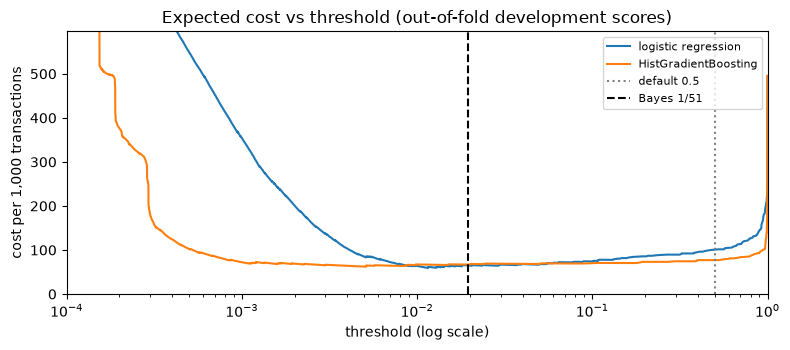

                      cost at 0.5  cost at Bayes 1/51  best threshold (in-sample)  best cost (in-sample)  flag nobody
logistic regression       101.538              64.765                       0.012                 59.269       497.05
HistGradientBoosting       76.996              66.920                       0.005                 62.151       497.05


In [15]:
from sklearn.metrics import confusion_matrix_at_thresholds

COST_FP, COST_FN = 1.0, 50.0
BAYES_THRESHOLD = COST_FP / (COST_FP + COST_FN)


def cost_per_1000(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return 1000 * (COST_FP * fp + COST_FN * fn) / len(y_true)


neg_cost_scorer = make_scorer(lambda y_true, y_pred: -cost_per_1000(y_true, y_pred))     # scorers maximize, so negate the cost

fig, ax = plt.subplots(figsize=(8, 3.6))
cost_rows = {}
for name in ["logistic regression", "HistGradientBoosting"]:
    tns, fps, fns, tps, thresholds = confusion_matrix_at_thresholds(fraud_y_dev, dev_scores[name])
    costs = 1000 * (COST_FP * fps + COST_FN * fns) / len(fraud_y_dev)
    ax.plot(thresholds, costs, label=name)
    at = lambda t: 1000 * (COST_FP * ((dev_scores[name] >= t) & (fraud_y_dev == 0)).sum() + COST_FN * ((dev_scores[name] < t) & (fraud_y_dev == 1)).sum()) / len(fraud_y_dev)
    cost_rows[name] = {"cost at 0.5": at(0.5), "cost at Bayes 1/51": at(BAYES_THRESHOLD), "best threshold (in-sample)": thresholds[costs.argmin()],
                       "best cost (in-sample)": costs.min(), "flag nobody": 1000 * COST_FN * fraud_y_dev.mean()}
ax.axvline(0.5, ls=":", color="gray", label="default 0.5")
ax.axvline(BAYES_THRESHOLD, ls="--", color="black", label="Bayes 1/51")
ax.set(xscale="log", xlim=(1e-4, 1), ylim=(0, 1000 * COST_FN * fraud_y_dev.mean() * 1.2), xlabel="threshold (log scale)",
       ylabel="cost per 1,000 transactions", title="Expected cost vs threshold (out-of-fold development scores)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
print(pd.DataFrame(cost_rows).T.round(3).to_string())

Now the proper workflow: carve a **validation** part out of the development data (the locked test set stays untouched), fit on the rest, and compare the default threshold, the Bayes threshold and a threshold tuned by internal CV.

In [16]:
thr_X_train, thr_X_val, thr_y_train, thr_y_val = train_test_split(fraud_X_dev, fraud_y_dev, test_size=0.3, stratify=fraud_y_dev, random_state=SEED)
hgb = HistGradientBoostingClassifier(random_state=SEED)
threshold_models = {
    "HGB, default threshold 0.5": clone(hgb),
    "HGB, FixedThresholdClassifier(1/51)": FixedThresholdClassifier(clone(hgb), threshold=BAYES_THRESHOLD),
    "HGB, TunedThresholdClassifierCV(cost)": TunedThresholdClassifierCV(clone(hgb), scoring=neg_cost_scorer, cv=dev_cv, store_cv_results=True),
}
threshold_rows = {}
for name, model in threshold_models.items():
    pred = model.fit(thr_X_train, thr_y_train).predict(thr_X_val)
    threshold_rows[name] = {"threshold": getattr(model, "best_threshold_", getattr(model, "threshold", 0.5)),
                            "validation cost / 1k": cost_per_1000(thr_y_val, pred), "recall": recall_score(thr_y_val, pred),
                            "precision": precision_score(thr_y_val, pred, zero_division=0.0), "alarms": int(pred.sum())}
threshold_table = pd.DataFrame(threshold_rows).T
print(threshold_table.round(4).to_string())
tuned = threshold_models["HGB, TunedThresholdClassifierCV(cost)"]
print(f"\ntuned threshold {tuned.best_threshold_:.4f} vs Bayes {BAYES_THRESHOLD:.4f}; validation cost drops from "
      f"{threshold_table.iloc[0]['validation cost / 1k']:.2f} (0.5) to {threshold_table['validation cost / 1k'].min():.2f} per 1,000 transactions")

                                       threshold  validation cost / 1k  recall  precision  alarms
HGB, default threshold 0.5                0.5000               54.2385  0.8919     0.9612   103.0
HGB, FixedThresholdClassifier(1/51)       0.0196               41.3973  0.9279     0.6280   164.0
HGB, TunedThresholdClassifierCV(cost)     0.0202               41.1279  0.9279     0.6398   161.0

tuned threshold 0.0202 vs Bayes 0.0196; validation cost drops from 54.24 (0.5) to 41.13 per 1,000 transactions


**Why tune on validation data only?** A threshold chosen on the same rows you report on is fitted to their noise. We split the validation part in two halves 20 times: pick the cheapest threshold on half A, then compare its cost on A (in-sample) with its cost on B (fresh rows).

In [17]:
val_scores = threshold_models["HGB, default threshold 0.5"].predict_proba(thr_X_val)[:, 1]
optimism_rows = []
for repeat in range(20):
    half_a, half_b = train_test_split(np.arange(len(thr_y_val)), test_size=0.5, stratify=thr_y_val, random_state=repeat)
    tns, fps, fns, tps, thresholds = confusion_matrix_at_thresholds(thr_y_val[half_a], val_scores[half_a])
    best_t = thresholds[np.argmin(COST_FP * fps + COST_FN * fns)]
    optimism_rows.append({"cost on A (where it was tuned)": cost_per_1000(thr_y_val[half_a], (val_scores[half_a] >= best_t).astype(int)),
                          "cost on B (fresh rows)": cost_per_1000(thr_y_val[half_b], (val_scores[half_b] >= best_t).astype(int))})
optimism = pd.DataFrame(optimism_rows)
print(optimism.agg(["mean", "std"]).round(3).to_string())
print(f"→ the in-sample cost is on average {optimism.iloc[:, 1].mean() - optimism.iloc[:, 0].mean():.2f} per 1,000 lower than the honest one "
      f"(B is higher in {(optimism.iloc[:, 1] > optimism.iloc[:, 0]).mean():.0%} of the 20 repeats)")

      cost on A (where it was tuned)  cost on B (fresh rows)
mean                          40.454                  42.062
std                            9.553                  10.985
→ the in-sample cost is on average 1.61 per 1,000 lower than the honest one (B is higher in 50% of the 20 repeats)


Here the optimism is small next to the noise, because the cost curve is flat near its minimum. It grows with smaller validation sets and when you search over many models *and* thresholds at once, and a test set used this way stops being a test set.

### ✍️ Your Turn

A medical screen says a missed disease costs 20 and an unnecessary follow-up costs 1. With calibrated probabilities, what is the Bayes-optimal threshold? Store it in `screen_threshold`.

In [18]:
screen_threshold = None  # TODO: your code here
check("screen_threshold", screen_threshold, 1 / 21, hint="C_FP / (C_FP + C_FN)")

⏳ screen_threshold: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
screen_threshold = 1 / (1 + 20)
check("screen_threshold", screen_threshold, 1 / 21)
```

≈ 0.048: refer anyone with at least a 4.8% risk. The rule only holds if probabilities are calibrated for the population being screened; otherwise tune on validation data.
</details>

> 💡 **Interview angle:** "How do you choose the classification threshold?" — from the decision: write down the costs (or a capacity / precision constraint), use $t^* = C_{FP}/(C_{FP}+C_{FN})$ if probabilities are calibrated, otherwise tune the threshold on validation data (`TunedThresholdClassifierCV`), never on the test set, and re-check it when the prevalence changes.

## 7. Calibration and Why Resampling Breaks It 🔴

A model is **calibrated** if, among cases given probability ≈ 0.1, about 10% are positive. A **reliability diagram** bins the predictions and plots mean predicted probability against the observed positive rate; the diagonal is perfect. (Calibration basics: [Naive Bayes, Section 11](06_Naive_Bayes.ipynb).)

**Why resampling and class weights break it.** A model trained on data with positive rate $\pi_s$ (say 50% after undersampling) learns probabilities for a world where fraud is common. Its log-odds are shifted by the change in prior odds. If the true rate is $\pi$, **prior correction** undoes it exactly (for a well-specified model):

$$\text{odds}_{\text{true}} = \text{odds}_{\text{sampled}} \times \frac{\pi / (1-\pi)}{\pi_s/(1-\pi_s)}, \qquad p = \frac{\text{odds}}{1 + \text{odds}}$$

`class_weight="balanced"` has the same effect as training at $\pi_s = 0.5$. Alternatively, recalibrate with `CalibratedClassifierCV` on data the model didn't train on: `method="sigmoid"` (Platt scaling: a logistic curve on the scores, 2 parameters) or `method="isotonic"` (a free-form increasing step function, needs more data).

                                              mean predicted P  actual rate   Brier  log loss  average precision
logistic regression                                     0.0100         0.01  0.0019    0.0096             0.9206
logistic regression on a 50:50 undersample              0.0959         0.01  0.0350    0.1499             0.8505
logistic regression, class_weight='balanced'            0.0786         0.01  0.0249    0.1086             0.9008
HistGradientBoosting                                    0.0102         0.01  0.0014    0.0088             0.9050
HistGradientBoosting + sigmoid calibration              0.0108         0.01  0.0014    0.0090             0.9093
HistGradientBoosting + isotonic calibration             0.0109         0.01  0.0014    0.0172             0.8992
undersample + prior correction                          0.0137         0.01  0.0037    0.0230             0.8505
class_weight + prior correction                         0.0118         0.01  0.0023    0.0144   

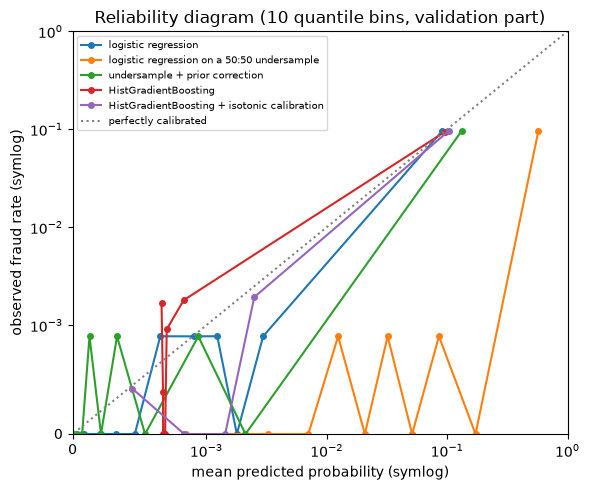

In [19]:
def correct_prior(p_sampled, true_rate, sampled_rate):
    """Map probabilities learned at positive rate `sampled_rate` back to the true positive rate."""
    p_sampled = np.clip(p_sampled, 1e-12, 1 - 1e-12)
    odds = p_sampled / (1 - p_sampled) * (true_rate / (1 - true_rate)) / (sampled_rate / (1 - sampled_rate))
    return odds / (1 + odds)


train_rate = thr_y_train.mean()
calibration_candidates = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "logistic regression on a 50:50 undersample": make_imb_pipeline(StandardScaler(), RandomUnderSampler(random_state=SEED), LogisticRegression(max_iter=3000)),
    "logistic regression, class_weight='balanced'": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, class_weight="balanced")),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=SEED),
    "HistGradientBoosting + sigmoid calibration": CalibratedClassifierCV(HistGradientBoostingClassifier(random_state=SEED), method="sigmoid", cv=dev_cv),
    "HistGradientBoosting + isotonic calibration": CalibratedClassifierCV(HistGradientBoostingClassifier(random_state=SEED), method="isotonic", cv=dev_cv),
}
calibrated_probas = {}
for name, model in calibration_candidates.items():
    calibrated_probas[name] = model.fit(thr_X_train, thr_y_train).predict_proba(thr_X_val)[:, 1]
calibrated_probas["undersample + prior correction"] = correct_prior(calibrated_probas["logistic regression on a 50:50 undersample"], train_rate, 0.5)
calibrated_probas["class_weight + prior correction"] = correct_prior(calibrated_probas["logistic regression, class_weight='balanced'"], train_rate, 0.5)

calibration_table = pd.DataFrame({name: {"mean predicted P": p.mean(), "actual rate": thr_y_val.mean(), "Brier": brier_score_loss(thr_y_val, p),
                                         "log loss": log_loss(thr_y_val, p), "average precision": average_precision_score(thr_y_val, p)}
                                  for name, p in calibrated_probas.items()}).T
print(calibration_table.round(5).to_string())
under, fixed = calibration_table.loc["logistic regression on a 50:50 undersample"], calibration_table.loc["undersample + prior correction"]
print(f"\nundersampling: mean P {under['mean predicted P']:.3f} vs actual {under['actual rate']:.4f}; after prior correction {fixed['mean predicted P']:.4f} "
      f"(log loss {under['log loss']:.3f} → {fixed['log loss']:.4f}); average precision unchanged: {under['average precision']:.4f} vs {fixed['average precision']:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
for name in ["logistic regression", "logistic regression on a 50:50 undersample", "undersample + prior correction",
             "HistGradientBoosting", "HistGradientBoosting + isotonic calibration"]:
    observed, predicted = calibration_curve(thr_y_val, calibrated_probas[name], n_bins=10, strategy="quantile")
    ax.plot(predicted, observed, marker="o", ms=4, label=name)
ax.plot([1e-5, 1], [1e-5, 1], ls=":", color="gray", label="perfectly calibrated")
ax.set(xscale="symlog", yscale="symlog", xlim=(0, 1), ylim=(0, 1), xlabel="mean predicted probability (symlog)", ylabel="observed fraud rate (symlog)",
       title="Reliability diagram (10 quantile bins, validation part)")
ax.set_xscale("symlog", linthresh=1e-3)
ax.set_yscale("symlog", linthresh=1e-3)
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

The undersampled and class-weighted models' probabilities are far too high. One line of arithmetic largely fixes them (log loss drops several-fold), because the problem is a known shift in the prior; the undersampled model still trails plain logistic regression because it threw most legitimate payments away. HistGradientBoosting was already well calibrated here: sigmoid calibration changed little and isotonic even worsened log loss (its step function can assign near-zero probabilities that a few frauds then punish), so calibrate when the reliability diagram shows a problem, and check the result. If you resample or re-weight and then use `predict_proba` for costs or risk, **correct or recalibrate first**.

### ✍️ Your Turn

A model trained on a 50:50 undersample outputs $p_s = 0.5$. The true positive rate is 1%. Apply prior correction and store the corrected probability in `corrected_p`.

In [20]:
corrected_p = None  # TODO: your code here
check("corrected_p", corrected_p, 0.01, hint="odds = 0.5/0.5 * (0.01/0.99) / (0.5/0.5); p = odds / (1 + odds)")

⏳ corrected_p: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
odds = (0.5 / 0.5) * (0.01 / 0.99) / (0.5 / 0.5)
corrected_p = odds / (1 + odds)
check("corrected_p", corrected_p, 0.01)
```

A 50/50 guess in the balanced world is exactly the base rate in the real world: the model had no evidence either way, so the prior wins.
</details>

> 💡 **Interview angle:** "You used SMOTE / class weights. Can you use `predict_proba` as a fraud probability?" — not directly: training at a different positive rate inflates probabilities. Apply prior correction (odds × true prior odds / training prior odds) or recalibrate with `CalibratedClassifierCV` on untouched data, and verify with a reliability diagram, Brier score and log loss.

## 8. Class Weights and Random Resampling 🟢

Two ways to make training care more about the rare class:

- **Class weights** multiply each sample's loss: `class_weight="balanced"` sets $w_c = \frac{n}{K\, n_c}$ (K classes), so the 2% malignant cases count ~25× more. No rows change.
- **Resampling** changes the training rows: `RandomOverSampler` duplicates minority rows, `RandomUnderSampler` drops majority rows.

Resamplers must only touch **training** data. imbalanced-learn's `Pipeline` calls `fit_resample` during `fit` and skips it during `predict` / `score`, so cross-validation resamples each training fold and leaves each validation fold untouched. scikit-learn's own `Pipeline` refuses samplers.

We compare on **mammography** (2.3% malignant) with the same 5 folds and several metrics: average precision and ROC-AUC (ranking), log loss (probability quality), and precision / recall at the default 0.5 threshold.

In [21]:
try:
    make_pipeline(StandardScaler(), RandomUnderSampler(random_state=SEED), LogisticRegression())
except TypeError as err:
    print("scikit-learn Pipeline + sampler →", str(err).split(".")[0])

print("training rows after resampling the whole mammography set (for illustration):")
for sampler in [RandomOverSampler(random_state=SEED), RandomUnderSampler(random_state=SEED)]:
    _, y_resampled = sampler.fit_resample(mammo_X, mammo_y)
    print(f"  {type(sampler).__name__:18s} {np.bincount(mammo_y).tolist()} → {np.bincount(y_resampled).tolist()}")

technique_scoring = {"average precision": "average_precision", "ROC-AUC": "roc_auc", "log loss": "neg_log_loss",
                     "recall@0.5": "recall", "precision@0.5": make_scorer(precision_score, zero_division=0.0)}
technique_rows = {}


def evaluate_technique(name, model, X=mammo_X, y=mammo_y, cv=mammo_cv):
    res = cross_validate(model, X, y, cv=cv, scoring=technique_scoring)
    technique_rows[name] = {"average precision": res["test_average precision"].mean(), "AP fold std": res["test_average precision"].std(),
                            "ROC-AUC": res["test_ROC-AUC"].mean(), "log loss": -res["test_log loss"].mean(),
                            "recall@0.5": res["test_recall@0.5"].mean(), "precision@0.5": res["test_precision@0.5"].mean(),
                            "fit s": res["fit_time"].mean()}


def logreg(**kwargs):
    return LogisticRegression(max_iter=5000, **kwargs)


evaluate_technique("LR", make_pipeline(StandardScaler(), logreg()))
evaluate_technique("LR, class_weight='balanced'", make_pipeline(StandardScaler(), logreg(class_weight="balanced")))
evaluate_technique("LR + random oversampling", make_imb_pipeline(StandardScaler(), RandomOverSampler(random_state=SEED), logreg()))
evaluate_technique("LR + random undersampling", make_imb_pipeline(StandardScaler(), RandomUnderSampler(random_state=SEED), logreg()))
print(pd.DataFrame(technique_rows).T.round(4).to_string())

training rows after resampling the whole mammography set (for illustration):
  RandomOverSampler  [10923, 260] → [10923, 10923]
  RandomUnderSampler [10923, 260] → [260, 260]


                             average precision  AP fold std  ROC-AUC  log loss  recall@0.5  precision@0.5   fit s
LR                                      0.6182       0.0461   0.9184    0.0578      0.4154         0.7791  0.0036
LR, class_weight='balanced'             0.5471       0.0626   0.9214    0.2952      0.8462         0.1688  0.0035
LR + random oversampling                0.5507       0.0661   0.9211    0.2970      0.8462         0.1664  0.0059
LR + random undersampling               0.5215       0.0595   0.9292    0.3146      0.8385         0.1554  0.0020


The pattern to remember: weighting and resampling trade precision for recall **at the default threshold** and inflate log loss (probabilities are shifted). They don't improve the **ranking**: ROC-AUC barely moves and average precision actually gets worse here. Most of their apparent effect is the same as moving the threshold — Section 11 tests that directly.

### ✍️ Your Turn

Compute the `"balanced"` class weights for `y_small = [0]*9 + [1]` with the formula $w_c = n / (K\, n_c)$ and store them as `[w_0, w_1]` in `balanced_weights`. (The checker uses `compute_class_weight`.)

In [22]:
y_small = np.array([0] * 9 + [1])
balanced_weights = None  # TODO: your code here
check("balanced_weights", balanced_weights, compute_class_weight("balanced", classes=np.array([0, 1]), y=y_small), hint="len(y_small) / (2 * np.bincount(y_small))")

⏳ balanced_weights: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_small = np.array([0] * 9 + [1])
balanced_weights = len(y_small) / (2 * np.bincount(y_small))
check("balanced_weights", balanced_weights, compute_class_weight("balanced", classes=np.array([0, 1]), y=y_small))
```

`[0.556, 5.0]`: each class's total weight becomes equal (9 × 0.556 = 1 × 5 = 5), exactly as if the data were balanced.
</details>

> 💡 **Interview angle:** "Class weights or resampling?" — class weights are simpler (no data changes, no extra rows, works with any weighted loss) and usually match random over/undersampling; undersampling is attractive for speed on huge data. Both shift probabilities and mostly act like a lower threshold, so compare against threshold tuning, and keep samplers inside an imbalanced-learn pipeline.

## 9. SMOTE, Its Variants and Cleaning Methods 🟡

**SMOTE** (Synthetic Minority Over-sampling TEchnique, Chawla et al. 2002) creates *new* minority points instead of duplicates:

1. For each minority point $x_i$, find its $k$ nearest **minority** neighbours (default $k = 5$).
2. Pick a random neighbour $x_{nn}$ and a random number $u \in [0, 1)$.
3. Create $x_{new} = x_i + u\,(x_{nn} - x_i)$: a point on the segment between them.

Variants focus the new points where they matter:

| Method | Idea |
|---|---|
| `BorderlineSMOTE` | only oversample minority points near the boundary (many majority neighbours, but not all) |
| `ADASYN` | generate more points around minority samples that are harder to learn (more majority neighbours) |
| `SMOTENC` | SMOTE for **mixed** numeric + categorical data: categories are taken from the neighbours, never interpolated |
| `TomekLinks` | remove majority points in "Tomek links" (pairs of mutual nearest neighbours from different classes) |
| `EditedNearestNeighbours` (ENN) | remove points whose neighbours mostly belong to another class |
| `SMOTETomek`, `SMOTEENN` | SMOTE, then clean |

All of these use distances, so **scale first**. The picture uses two standardized mammography features and a random 3,000 rows (a 2-D view for intuition only).

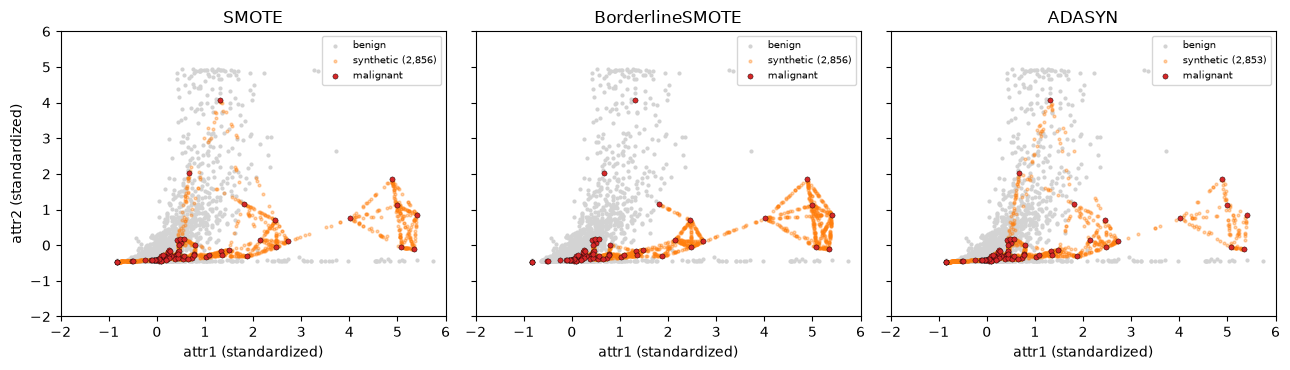

In [23]:
view_rows = rng.choice(len(mammo_X), 3_000, replace=False)
view_X = StandardScaler().fit_transform(mammo_X[view_rows][:, :2])
view_y = mammo_y[view_rows]
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True, sharey=True)
for ax, sampler in zip(axes, [SMOTE(random_state=SEED), BorderlineSMOTE(random_state=SEED), ADASYN(random_state=SEED)]):
    X_res, y_res = sampler.fit_resample(view_X, view_y)
    synthetic = X_res[len(view_X):]
    ax.scatter(view_X[view_y == 0, 0], view_X[view_y == 0, 1], s=4, color="lightgray", label="benign")
    ax.scatter(synthetic[:, 0], synthetic[:, 1], s=4, color="tab:orange", alpha=0.35, label=f"synthetic ({len(synthetic):,})")
    ax.scatter(view_X[view_y == 1, 0], view_X[view_y == 1, 1], s=14, color="tab:red", edgecolor="k", linewidth=0.3, label="malignant")
    ax.set(title=type(sampler).__name__, xlabel="attr1 (standardized)", xlim=(-2, 6), ylim=(-2, 6))
    ax.legend(fontsize=7, loc="upper right")
axes[0].set_ylabel("attr2 (standardized)")
plt.tight_layout()
plt.show()

SMOTE fills the space between malignant points (including across benign regions), Borderline-SMOTE concentrates on the overlap, and ADASYN piles points where malignant cases are surrounded by benign ones. Now the numbers, same folds and metrics as Section 8:

In [24]:
resamplers = {
    "LR + SMOTE": SMOTE(random_state=SEED),
    "LR + Borderline-SMOTE": BorderlineSMOTE(random_state=SEED),
    "LR + ADASYN": ADASYN(random_state=SEED),
    "LR + Tomek links (cleaning)": TomekLinks(),
    "LR + ENN (cleaning)": EditedNearestNeighbours(),
    "LR + SMOTE-Tomek": SMOTETomek(random_state=SEED),
    "LR + SMOTE-ENN": SMOTEENN(random_state=SEED),
}
for name, sampler in resamplers.items():
    evaluate_technique(name, make_imb_pipeline(StandardScaler(), sampler, logreg()))
technique_table = pd.DataFrame(technique_rows).T.sort_values("average precision", ascending=False)
print(technique_table.round(4).to_string())
lr_ap, lr_std = technique_table.loc["LR", "average precision"], technique_table.loc["LR", "AP fold std"]
better = technique_table.index[technique_table["average precision"] > lr_ap + lr_std].tolist()
print(f"\nplain LR: AP {lr_ap:.4f} ± {lr_std:.4f}. Techniques beating it by more than one fold std: {better if better else 'none'}. "
      f"Highest log loss (worst probabilities): {technique_table['log loss'].idxmax()}.")

                             average precision  AP fold std  ROC-AUC  log loss  recall@0.5  precision@0.5   fit s
LR + Tomek links (cleaning)             0.6197       0.0472   0.9186    0.0578      0.4385         0.7926  0.0478
LR                                      0.6182       0.0461   0.9184    0.0578      0.4154         0.7791  0.0036
LR + ENN (cleaning)                     0.6157       0.0563   0.9186    0.0601      0.4885         0.7292  0.0508
LR + random oversampling                0.5507       0.0661   0.9211    0.2970      0.8462         0.1664  0.0059
LR, class_weight='balanced'             0.5471       0.0626   0.9214    0.2952      0.8462         0.1688  0.0035
LR + SMOTE-Tomek                        0.5413       0.0673   0.9202    0.2857      0.8500         0.1707  0.0674
LR + SMOTE                              0.5410       0.0670   0.9212    0.2870      0.8500         0.1705  0.0066
LR + random undersampling               0.5215       0.0595   0.9292    0.3146      0.83

**Mixed data: SMOTE-NC.** Plain SMOTE only understands numbers. On census data with categorical columns, `SMOTENC(categorical_features="auto")` interpolates the numeric columns and picks the most frequent category among the neighbours for each categorical column, so every synthetic person has a real workclass, education and so on (Pitfall 1 shows what goes wrong otherwise).

In [25]:
adult = openml(name="adult", version=2)
adult_sample = adult.data.sample(4_000, random_state=SEED)
adult_sample = adult_sample.apply(lambda s: s.cat.add_categories("missing").fillna("missing") if s.dtype == "category" else s)
adult_sample_y = (adult.target.loc[adult_sample.index] == ">50K").astype(int).to_numpy()
smotenc = SMOTENC(categorical_features="auto", random_state=SEED)
adult_resampled, adult_resampled_y = smotenc.fit_resample(adult_sample, adult_sample_y)
synthetic_people = adult_resampled.iloc[len(adult_sample):]
valid = all(synthetic_people[col].isin(adult_sample[col].cat.categories).all() for col in adult_sample.select_dtypes("category"))
print(f"{np.bincount(adult_sample_y).tolist()} → {np.bincount(adult_resampled_y).tolist()} | every synthetic category is a real category: {valid}")
print(synthetic_people[["age", "workclass", "education", "occupation", "hours-per-week"]].head(3).to_string())

[3038, 962] → [3038, 3038] | every synthetic category is a real category: True
      age workclass  education       occupation  hours-per-week
4000   38   Private  Bachelors  Exec-managerial              54
4001   49   Private  Bachelors  Exec-managerial              49
4002   49   Private  Bachelors   Prof-specialty              41


### ✍️ Your Turn

Create one SMOTE sample by hand from minority point `x_i = [1, 2]`, its chosen neighbour `x_nn = [3, 6]` and random step `u = 0.25`. Store it in `synthetic_point`.

In [26]:
x_i, x_nn, u = np.array([1.0, 2.0]), np.array([3.0, 6.0]), 0.25
synthetic_point = None  # TODO: your code here
check("synthetic_point", synthetic_point, [1.5, 3.0], hint="x_i + u * (x_nn - x_i)")

⏳ synthetic_point: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
x_i, x_nn, u = np.array([1.0, 2.0]), np.array([3.0, 6.0]), 0.25
synthetic_point = x_i + u * (x_nn - x_i)
check("synthetic_point", synthetic_point, [1.5, 3.0])
```

A quarter of the way from `x_i` to its neighbour. Every SMOTE point lies on such a segment — the property we assert in Build It From Scratch.
</details>

> 💡 **Interview angle:** "How does SMOTE work, and when does it hurt?" — it interpolates between a minority point and one of its k minority neighbours. It can help weak learners with few positives, but it creates noise where classes overlap, ignores categorical semantics (use SMOTE-NC), needs scaling, distorts probabilities, must run inside the training folds, and often gives no gain over class weights + threshold tuning for strong models.

## 10. The SMOTE-Before-Splitting Leak 🔴

The most common imbalanced-data bug: oversample the whole dataset, **then** split or cross-validate. Synthetic points are interpolations of real minority points, so a validation fold ends up containing near-copies of training points (and real points whose synthetic "children" sit in training). The model is rewarded for memorizing.

**Experiment on mammography:** lock away 25% as a test set. On the remaining 75%, compare ❌ SMOTE first, then 5-fold CV, with ✅ SMOTE inside an imbalanced-learn pipeline, and check both against the test set.

In [27]:
mam_dev_X, mam_test_X, mam_dev_y, mam_test_y = train_test_split(mammo_X, mammo_y, test_size=0.25, stratify=mammo_y, random_state=SEED)
leak_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
leak_models = {"logistic regression": lambda: make_pipeline(StandardScaler(), logreg()),
               "random forest (200 trees)": lambda: RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=4)}
smote_leak_rows = {}
X_smoted, y_smoted = SMOTE(random_state=SEED).fit_resample(mam_dev_X, mam_dev_y)            # ❌ before any split
for name, build in leak_models.items():
    leaky = cross_val_score(build(), X_smoted, y_smoted, cv=leak_folds, scoring="average_precision").mean()
    steps = build()
    honest_pipe = make_imb_pipeline(*(list(steps.named_steps.values()) if hasattr(steps, "named_steps") else [steps])[:-1],
                                    SMOTE(random_state=SEED), (steps[-1] if hasattr(steps, "named_steps") else steps))
    honest = cross_val_score(honest_pipe, mam_dev_X, mam_dev_y, cv=leak_folds, scoring="average_precision").mean()
    test = average_precision_score(mam_test_y, honest_pipe.fit(mam_dev_X, mam_dev_y).predict_proba(mam_test_X)[:, 1])
    smote_leak_rows[name] = {"❌ SMOTE then CV: AP": leaky, "✅ SMOTE inside CV: AP": honest, "test AP (truth)": test}
smote_leak = pd.DataFrame(smote_leak_rows).T
print(f"after SMOTE on all development rows: {np.bincount(y_smoted).tolist()} ({(len(y_smoted) - len(mam_dev_y)):,} synthetic malignant rows; "
      f"validation folds' 'malignant' cases are {1 - mam_dev_y.sum() / y_smoted.sum():.0%} synthetic)")
print(smote_leak.round(4).to_string())
for name, row in smote_leak.iterrows():
    print(f"{name}: the leaky estimate overstates the test AP by {row.iloc[0] - row.iloc[2]:+.3f}; the honest one is off by {row.iloc[1] - row.iloc[2]:+.3f}")
del X_smoted, y_smoted

after SMOTE on all development rows: [8192, 8192] (7,997 synthetic malignant rows; validation folds' 'malignant' cases are 98% synthetic)
                           ❌ SMOTE then CV: AP  ✅ SMOTE inside CV: AP  test AP (truth)
logistic regression                     0.9348                 0.5008           0.5051
random forest (200 trees)               0.9947                 0.7031           0.7496
logistic regression: the leaky estimate overstates the test AP by +0.430; the honest one is off by -0.004
random forest (200 trees): the leaky estimate overstates the test AP by +0.245; the honest one is off by -0.047


Both models are fooled. The leaky random forest scores an almost perfect AP because it memorizes training points and the synthetic near-duplicates in the validation folds look like "correct predictions"; logistic regression's estimate is inflated even more in absolute terms, because nearly all "malignant" validation cases are easy synthetic interpolations. The same leak happens with `RandomOverSampler` (exact duplicates) and with any resampling done before `train_test_split`.

> 💡 **Interview angle:** "You oversampled with SMOTE and got 0.99 CV AUC. Why don't I believe it?" — if SMOTE ran before splitting, validation folds contain synthetic interpolations of training points (near-duplicates), so the score measures memorization. Resample only inside training folds (`imblearn.pipeline.Pipeline`), evaluate on untouched, naturally imbalanced data.

## 11. Balanced Ensembles and the Honest Verdict 🔴

imbalanced-learn also ships ensembles that resample **per base learner**:

- **`BalancedRandomForestClassifier`**: each tree sees a bootstrap sample with the majority class undersampled to the minority size (Chen, Liaw & Breiman, 2004). Every tree is balanced; together they still see most of the data.
- **`EasyEnsembleClassifier`**: AdaBoost learners, each trained on a different balanced undersample (Liu, Wu & Zhou, 2009).

First, how they compare with plain forests and gradient boosting on mammography (same folds and metrics as before):

In [28]:
evaluate_technique("random forest (300 trees)", RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=4))
evaluate_technique("Balanced Random Forest (300 trees)", BalancedRandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=4))
evaluate_technique("EasyEnsemble (10 AdaBoost learners)", EasyEnsembleClassifier(n_estimators=10, random_state=SEED, n_jobs=4))
evaluate_technique("HistGradientBoosting", HistGradientBoostingClassifier(random_state=SEED))
evaluate_technique("HistGradientBoosting, class_weight='balanced'", HistGradientBoostingClassifier(class_weight="balanced", random_state=SEED))
ensemble_names = ["random forest (300 trees)", "Balanced Random Forest (300 trees)", "EasyEnsemble (10 AdaBoost learners)",
                  "HistGradientBoosting", "HistGradientBoosting, class_weight='balanced'"]
print(pd.DataFrame(technique_rows).T.loc[ensemble_names].round(4).to_string())

                                               average precision  AP fold std  ROC-AUC  log loss  recall@0.5  precision@0.5   fit s
random forest (300 trees)                                 0.7567       0.0387   0.9532    0.0609      0.5538         0.8646  0.2679
Balanced Random Forest (300 trees)                        0.6952       0.0337   0.9551    0.1784      0.8538         0.3143  0.2910
EasyEnsemble (10 AdaBoost learners)                       0.6303       0.0499   0.9390    0.5466      0.8615         0.1529  0.3645
HistGradientBoosting                                      0.7316       0.0416   0.9373    0.0515      0.5808         0.7931  0.3927
HistGradientBoosting, class_weight='balanced'             0.7050       0.0424   0.9089    0.0772      0.7000         0.6601  0.7383


**The honest verdict.** Metrics at 0.5 are unfair to plain models: their threshold is just in the wrong place. The fair comparison gives **every** strategy its own tuned threshold (tuned by internal CV on the training folds) and compares the resulting decisions, here by F1 on the malignant class, plus average precision for the ranking.

In [29]:
verdict_strategies = {
    "LR + tuned threshold": make_pipeline(StandardScaler(), logreg()),
    "LR class_weight + tuned threshold": make_pipeline(StandardScaler(), logreg(class_weight="balanced")),
    "LR + SMOTE + tuned threshold": make_imb_pipeline(StandardScaler(), SMOTE(random_state=SEED), logreg()),
    "HGB + tuned threshold": HistGradientBoostingClassifier(random_state=SEED),
    "HGB + SMOTE + tuned threshold": make_imb_pipeline(SMOTE(random_state=SEED), HistGradientBoostingClassifier(random_state=SEED)),
    "Balanced RF + tuned threshold": BalancedRandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=4),
}
verdict_rows = {}
for name, estimator in verdict_strategies.items():
    tuned_model = TunedThresholdClassifierCV(estimator, scoring="f1", cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED))
    res = cross_validate(tuned_model, mammo_X, mammo_y, cv=mammo_cv, scoring={"F1 at tuned threshold": "f1", "average precision": "average_precision"})
    verdict_rows[name] = {"F1 at tuned threshold": res["test_F1 at tuned threshold"].mean(), "F1 fold std": res["test_F1 at tuned threshold"].std(),
                          "average precision": res["test_average precision"].mean()}
verdict = pd.DataFrame(verdict_rows).T.sort_values("F1 at tuned threshold", ascending=False)
print(verdict.round(4).to_string())
best_plain = verdict.loc[["LR + tuned threshold", "LR class_weight + tuned threshold", "HGB + tuned threshold"], "F1 at tuned threshold"].max()
best_resampled = verdict.loc[["LR + SMOTE + tuned threshold", "HGB + SMOTE + tuned threshold", "Balanced RF + tuned threshold"], "F1 at tuned threshold"].max()
print(f"\nbest without resampling: F1 {best_plain:.4f} | best with resampling: F1 {best_resampled:.4f} | difference {best_resampled - best_plain:+.4f} "
      f"vs typical fold std {verdict['F1 fold std'].mean():.4f} → "
      f"{'resampling wins clearly' if best_resampled - best_plain > verdict['F1 fold std'].mean() else 'no clear win for resampling' if best_resampled - best_plain > -verdict['F1 fold std'].mean() else 'resampling is clearly worse'}")

                                   F1 at tuned threshold  F1 fold std  average precision
HGB + SMOTE + tuned threshold                     0.7228       0.0311             0.7526
HGB + tuned threshold                             0.7020       0.0428             0.7316
Balanced RF + tuned threshold                     0.6515       0.0420             0.6952
LR + tuned threshold                              0.5998       0.0310             0.6182
LR class_weight + tuned threshold                 0.5693       0.0277             0.5471
LR + SMOTE + tuned threshold                      0.5637       0.0364             0.5410

best without resampling: F1 0.7020 | best with resampling: F1 0.7228 | difference +0.0208 vs typical fold std 0.0352 → no clear win for resampling


One dataset is one data point. Let's repeat the ranking comparison (average precision, 5-fold CV) on seven more real imbalanced datasets from imbalanced-learn's benchmark collection.

In [30]:
benchmark_names = ("abalone_19", "oil", "us_crime", "coil_2000", "yeast_me2", "ozone_level", "solar_flare_m0")
benchmark = fetch_datasets(data_home=str(IMBLEARN_HOME), filter_data=benchmark_names)      # this function wants a str path
benchmark_strategies = {
    "LR": lambda: make_pipeline(StandardScaler(), logreg()),
    "LR class_weight": lambda: make_pipeline(StandardScaler(), logreg(class_weight="balanced")),
    "LR + SMOTE": lambda: make_imb_pipeline(StandardScaler(), SMOTE(random_state=SEED), logreg()),
    "HGB": lambda: HistGradientBoostingClassifier(random_state=SEED),
    "HGB + SMOTE": lambda: make_imb_pipeline(SMOTE(random_state=SEED), HistGradientBoostingClassifier(random_state=SEED)),
    "Balanced RF": lambda: BalancedRandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=4),
}
benchmark_rows = {}
for dataset_name in benchmark_names:
    bunch = benchmark[dataset_name]
    y_bench = (bunch.target == 1).astype(int)
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    row = {"rows": len(y_bench), "positive rate": y_bench.mean()}
    for strategy, build in benchmark_strategies.items():
        row[strategy] = cross_val_score(build(), bunch.data, y_bench, cv=folds, scoring="average_precision").mean()
    benchmark_rows[dataset_name] = row
bench = pd.DataFrame(benchmark_rows).T
print(bench.round(3).to_string())
plain_cols, resampled_cols = ["LR", "LR class_weight", "HGB"], ["LR + SMOTE", "HGB + SMOTE", "Balanced RF"]
margin = bench[resampled_cols].max(axis=1) - bench[plain_cols].max(axis=1)
print(f"\nbest resampling strategy minus best non-resampling strategy (AP): {margin.round(3).to_dict()}")
print(f"resampling ahead by > 0.02 AP on {(margin > 0.02).sum()} of {len(margin)} datasets, behind by > 0.02 on {(margin < -0.02).sum()}, "
      f"within ±0.02 on {(margin.abs() <= 0.02).sum()}")

                  rows  positive rate     LR  LR class_weight  LR + SMOTE    HGB  HGB + SMOTE  Balanced RF
abalone_19      4177.0          0.008  0.042            0.039       0.039  0.068        0.068        0.049
oil              937.0          0.044  0.575            0.516       0.515  0.584        0.650        0.544
us_crime        1994.0          0.075  0.587            0.563       0.525  0.590        0.561        0.544
coil_2000       9822.0          0.060  0.166            0.161       0.155  0.156        0.159        0.160
yeast_me2       1484.0          0.034  0.393            0.323       0.351  0.428        0.417        0.391
ozone_level     2536.0          0.029  0.278            0.232       0.223  0.337        0.314        0.361
solar_flare_m0  1389.0          0.049  0.258            0.239       0.219  0.190        0.153        0.194

best resampling strategy minus best non-resampling strategy (AP): {'abalone_19': -0.001, 'oil': 0.066, 'us_crime': -0.029, 'coil_2000': -0.005,

Read your own numbers above rather than a slogan. The usual finding, which these experiments test, is that once every model gets a sensible threshold, **class weights or plain models plus threshold tuning are about as good as resampling**, and resampling adds complexity, compute and miscalibrated probabilities. Resampling (or balanced ensembles) can still win on particular datasets, especially with weak learners and very few positives, so treat it as one more hyperparameter to validate, not a default.

> 💡 **Interview angle:** "Do you always use SMOTE for imbalanced data?" — no. First choose the right metric and tune the threshold; try class weights; treat resampling as a hyperparameter validated inside CV. Recent practice (and imbalanced-learn's own maintainers) favour well-calibrated strong models plus cost-based thresholds; SMOTE mostly helps weak learners with very few positives.

## 12. An Honest Evaluation Protocol 🔴

| Step | Why | Tool |
|---|---|---|
| **Stratified** splits | every fold gets its share of the rare class | `StratifiedKFold`, `train_test_split(stratify=y)` |
| **Grouped** splits | rows from the same customer / patient / family must not straddle train and validation | `GroupKFold`, `StratifiedGroupKFold` |
| **Time-based** splits | the future can't train the past | `TimeSeriesSplit`, a cutoff date |
| **Nested CV** | the score used to *choose* hyperparameters is optimistic | `cross_val_score(GridSearchCV(...))` |
| **Confidence intervals** | one number hides its uncertainty (few positives → wide intervals) | bootstrap the test rows |
| **Paired comparisons** | "B beats A" must survive noise; use the same folds | per-fold differences, corrected t-test, McNemar |
| **Test set once** | every look at the test set turns it into validation data | lock it away until the end |

**Stratification.** With ~370 frauds, plain 10-fold CV can give folds with noticeably different fraud counts:

In [31]:
fold_counts = {}
for name, splitter in [("KFold(shuffle)", KFold(n_splits=10, shuffle=True, random_state=SEED)),
                       ("StratifiedKFold", StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED))]:
    counts = [int(fraud_y_dev[valid_idx].sum()) for _, valid_idx in splitter.split(fraud_X_dev, fraud_y_dev)]
    fold_counts[name] = {"min frauds in a fold": min(counts), "max frauds in a fold": max(counts), "std": np.std(counts)}
print(pd.DataFrame(fold_counts).T.to_string())

                 min frauds in a fold  max frauds in a fold     std
KFold(shuffle)                   22.0                  43.0  6.4568
StratifiedKFold                  36.0                  37.0  0.3000


**Groups.** Titanic passengers travelling together share a ticket, a fare, a cabin class and often the same fate. If family members sit on both sides of a split, a flexible model can recognise the family instead of learning general patterns. `StratifiedGroupKFold` keeps each ticket group inside one fold while balancing the survival rate.

In [32]:
titanic = openml(name="titanic", version=1).frame
titanic_features = titanic[["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]]
titanic_target = titanic["survived"].astype(int).to_numpy()
ticket_groups = titanic["ticket"].to_numpy()
titanic_model = make_pipeline(
    ColumnTransformer([("num", SimpleImputer(strategy="median"), ["pclass", "age", "sibsp", "parch", "fare"]),
                       ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")), ["sex", "embarked"])]),
    RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=4))
group_rows = {}
for name, splitter in [("StratifiedKFold (groups ignored)", StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)),
                       ("StratifiedGroupKFold (tickets kept together)", StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED))]:
    group_kwargs = {"groups": ticket_groups} if isinstance(splitter, StratifiedGroupKFold) else {}     # only group splitters use groups
    scores = cross_val_score(titanic_model, titanic_features, titanic_target, cv=splitter, scoring="roc_auc", **group_kwargs)
    group_rows[name] = {"CV ROC-AUC": scores.mean(), "fold std": scores.std()}
group_table = pd.DataFrame(group_rows).T
print(f"{pd.Series(ticket_groups).value_counts().gt(1).sum()} tickets are shared by 2+ passengers")
print(group_table.round(4).to_string())
print(f"ignoring groups changes the estimate by {group_table.iloc[0, 0] - group_table.iloc[1, 0]:+.4f} AUC")

216 tickets are shared by 2+ passengers
                                              CV ROC-AUC  fold std
StratifiedKFold (groups ignored)                  0.8466    0.0254
StratifiedGroupKFold (tickets kept together)      0.8275    0.0276
ignoring groups changes the estimate by +0.0191 AUC


**Time.** The electricity dataset records whether the New South Wales price went up or down every 30 minutes over 2.5 years. Shuffled CV lets the model train on the half-hours right after the ones it's tested on; a time-based split doesn't.

In [33]:
electricity = openml(data_id=151)
elec_X, elec_y = electricity.data, (electricity.target == "UP").astype(int).to_numpy()
elec_rows = {}
for name, splitter in [("StratifiedKFold, shuffled", StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)),
                       ("TimeSeriesSplit (train on the past)", TimeSeriesSplit(n_splits=5))]:
    scores = cross_val_score(HistGradientBoostingClassifier(categorical_features="from_dtype", random_state=SEED), elec_X, elec_y, cv=splitter, scoring="roc_auc")
    elec_rows[name] = {"CV ROC-AUC": scores.mean(), "fold std": scores.std()}
elec_table = pd.DataFrame(elec_rows).T
print(elec_table.round(4).to_string())
print(f"shuffling overstates the performance you'd get on future data by {elec_table.iloc[0, 0] - elec_table.iloc[1, 0]:+.4f} AUC")

                                     CV ROC-AUC  fold std
StratifiedKFold, shuffled                0.9560    0.0017
TimeSeriesSplit (train on the past)      0.8318    0.0522
shuffling overstates the performance you'd get on future data by +0.1241 AUC


**Nested CV.** If you pick hyperparameters by their CV score, that best score is biased upward (you selected the luckiest configuration). Nested CV wraps the whole search in an outer loop.

In [34]:
search = GridSearchCV(make_pipeline(StandardScaler(), logreg()),
                      {"logisticregression__C": [0.001, 0.01, 0.1, 1, 10], "logisticregression__class_weight": [None, "balanced"]},
                      cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=1), scoring="average_precision")
non_nested = search.fit(mammo_X, mammo_y).best_score_
nested = cross_val_score(search, mammo_X, mammo_y, cv=mammo_cv, scoring="average_precision")
print(f"best inner CV score (used to choose): AP {non_nested:.4f} | nested CV estimate: AP {nested.mean():.4f} ± {nested.std():.4f} "
      f"| optimism {non_nested - nested.mean():+.4f} (with only 10 candidates; it grows with bigger searches)")

best inner CV score (used to choose): AP 0.6217 | nested CV estimate: AP 0.6204 ± 0.0448 | optimism +0.0013 (with only 10 candidates; it grows with bigger searches)


**Bootstrap confidence intervals.** Resample the evaluation rows with replacement many times, recompute the metric each time, and read off the 2.5th and 97.5th percentiles. With few positives, intervals are wide, and that's important to report.

In [35]:
def bootstrap_ci(y_true, y_score, metric, n_boot=1_000, seed=SEED):
    boot_rng = np.random.default_rng(seed)
    values = []
    for _ in range(n_boot):
        idx = boot_rng.integers(0, len(y_true), len(y_true))
        if y_true[idx].min() == y_true[idx].max():          # a resample without positives can't be scored
            continue
        values.append(metric(y_true[idx], y_score[idx]))
    return np.percentile(values, [2.5, 97.5])


hgb_val_pred = (val_scores >= tuned.best_threshold_).astype(int)
ap_low, ap_high = bootstrap_ci(thr_y_val, val_scores, average_precision_score)
cost_low, cost_high = bootstrap_ci(thr_y_val, hgb_val_pred, cost_per_1000)
print(f"HistGradientBoosting on the validation part ({thr_y_val.sum()} frauds): AP {average_precision_score(thr_y_val, val_scores):.3f} "
      f"[95% CI {ap_low:.3f}–{ap_high:.3f}] | cost per 1,000 at the tuned threshold {cost_per_1000(thr_y_val, hgb_val_pred):.2f} [{cost_low:.2f}–{cost_high:.2f}]")

HistGradientBoosting on the validation part (111 frauds): AP 0.905 [95% CI 0.839–0.958] | cost per 1,000 at the tuned threshold 41.13 [21.40–68.97]


**Comparing two models.** Use the **same folds** for both and look at per-fold differences. Folds share training data, so the naive t-test is overconfident; the **Nadeau–Bengio corrected** t-test inflates the variance by $\left(\frac1k + \frac{n_{test}}{n_{train}}\right)$ instead of $\frac1k$. For two classifiers evaluated on one test set, **McNemar's test** checks whether they make different mistakes: it only uses the rows where exactly one model is right.

In [36]:
repeated = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=SEED)
ap_lr = cross_val_score(make_pipeline(StandardScaler(), logreg()), fraud_X_dev, fraud_y_dev, cv=repeated, scoring="average_precision")
ap_hgb = cross_val_score(HistGradientBoostingClassifier(random_state=SEED), fraud_X_dev, fraud_y_dev, cv=repeated, scoring="average_precision")
diff = ap_hgb - ap_lr
k, test_train_ratio = len(diff), 1 / 4
naive_t = diff.mean() / np.sqrt(diff.var(ddof=1) / k)
corrected_t = diff.mean() / np.sqrt(diff.var(ddof=1) * (1 / k + test_train_ratio))
p_naive = 2 * stats.t.sf(abs(naive_t), df=k - 1)
p_corrected = 2 * stats.t.sf(abs(corrected_t), df=k - 1)
print(f"AP over 20 paired folds: LR {ap_lr.mean():.4f}, HGB {ap_hgb.mean():.4f}, mean difference {diff.mean():+.4f}; "
      f"HGB wins {np.mean(diff > 0):.0%} of folds")
print(f"naive paired t-test p = {p_naive:.4f} | Nadeau–Bengio corrected p = {p_corrected:.4f} → "
      f"{'significant' if p_corrected < 0.05 else 'not significant'} at 5% after correction")

lr_val_pred = (clone(lr_pipe).fit(thr_X_train, thr_y_train).predict_proba(thr_X_val)[:, 1] >= BAYES_THRESHOLD).astype(int)
hgb_bayes_pred = (val_scores >= BAYES_THRESHOLD).astype(int)
both = pd.crosstab(lr_val_pred == thr_y_val, hgb_bayes_pred == thr_y_val).reindex(index=[True, False], columns=[True, False], fill_value=0)
result = mcnemar(both.to_numpy(), exact=bool(both.iloc[0, 1] + both.iloc[1, 0] < 25))
print(f"\nMcNemar on the validation part (both at threshold 1/51): LR right & HGB wrong = {both.loc[True, False]}, "
      f"LR wrong & HGB right = {both.loc[False, True]}, p = {result.pvalue:.4f} → "
      f"{'the models make significantly different numbers of mistakes' if result.pvalue < 0.05 else 'no significant difference in error counts'}")

AP over 20 paired folds: LR 0.8757, HGB 0.8889, mean difference +0.0132; HGB wins 85% of folds
naive paired t-test p = 0.0046 | Nadeau–Bengio corrected p = 0.2056 → not significant at 5% after correction

McNemar on the validation part (both at threshold 1/51): LR right & HGB wrong = 42, LR wrong & HGB right = 86, p = 0.0001 → the models make significantly different numbers of mistakes


### ✍️ Your Turn

For 5-fold CV repeated 4 times (20 paired differences, each training set 4× the size of its test fold), compute the Nadeau–Bengio variance factor $\frac1k + \frac{n_{test}}{n_{train}}$ and store it in `nb_factor`.

In [37]:
nb_factor = None  # TODO: your code here
check("nb_factor", nb_factor, 0.3, hint="1 / 20 + 1 / 4")

⏳ nb_factor: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
nb_factor = 1 / 20 + 1 / 4
check("nb_factor", nb_factor, 0.3)
```

The naive factor would be 1/20 = 0.05, six times smaller: the naive test pretends the 20 folds are independent, although their training sets overlap heavily.
</details>

> 💡 **Interview angle:** "How do you know model B is really better than model A?" — same splits for both, respect groups and time, look at paired per-fold differences with a corrected t-test (or McNemar / a paired bootstrap on one test set), report confidence intervals, check the difference is practically meaningful, and only then confirm once on the untouched test set.

## 🔧 Build It From Scratch

### Part A — Precision–recall curve, average precision, ROC curve and AUC in NumPy

All four come from one pass over the scores sorted from high to low:

1. Sort by score (descending). Tied scores must be treated as **one** threshold, so keep only the last position of each run of equal scores.
2. At each distinct threshold, the cumulative sums give TP (positives above it) and FP (negatives above it).
3. Precision = TP / (TP + FP), recall = TP / P, FPR = FP / N.
4. **Average precision** = $\sum_n (R_n - R_{n-1})\, P_n$ (a step function, no interpolation). **ROC-AUC** = trapezoid area under (FPR, TPR) starting at (0, 0), which also equals the Mann–Whitney probability that a random positive outranks a random negative (ties count ½).

In [38]:
def scratch_curves(y_true, scores):
    y_true, scores = np.asarray(y_true), np.asarray(scores, dtype=float)
    order = np.argsort(scores, kind="mergesort")[::-1]                       # high → low
    y_sorted, s_sorted = y_true[order], scores[order]
    last_of_run = np.r_[np.flatnonzero(np.diff(s_sorted)), len(s_sorted) - 1]   # one threshold per distinct score
    tps = np.cumsum(y_sorted)[last_of_run].astype(float)
    fps = (last_of_run + 1) - tps
    thresholds = s_sorted[last_of_run]
    precision = tps / (tps + fps)
    recall = tps / tps[-1]
    fpr, tpr = np.r_[0.0, fps / fps[-1]], np.r_[0.0, tps / tps[-1]]
    average_precision = np.sum(np.diff(np.r_[0.0, recall]) * precision)
    roc_auc = np.sum(np.diff(fpr) * (tpr[1:] + tpr[:-1]) / 2)                    # trapezoid rule
    return {"precision": precision, "recall": recall, "thresholds": thresholds, "fpr": fpr, "tpr": tpr, "AP": average_precision, "AUC": roc_auc}


test_cases = {"logistic regression (continuous scores)": dev_scores["logistic regression"],
              "HistGradientBoosting rounded to 2 decimals (many ties)": np.round(dev_scores["HistGradientBoosting"], 2)}
for name, scores in test_cases.items():
    ours = scratch_curves(fraud_y_dev, scores)
    sk_precision, sk_recall, sk_thresholds = precision_recall_curve(fraud_y_dev, scores)
    sk_fpr, sk_tpr, _ = roc_curve(fraud_y_dev, scores, drop_intermediate=False)
    # scikit-learn orders the PR curve by increasing threshold and appends the (precision=1, recall=0) end point
    assert np.allclose(ours["precision"][::-1], sk_precision[:-1]) and np.allclose(ours["recall"][::-1], sk_recall[:-1])
    assert np.allclose(ours["thresholds"][::-1], sk_thresholds)
    assert np.allclose(ours["fpr"], sk_fpr) and np.allclose(ours["tpr"], sk_tpr)
    assert np.isclose(ours["AP"], average_precision_score(fraud_y_dev, scores))
    assert np.isclose(ours["AUC"], roc_auc_score(fraud_y_dev, scores))
    u_statistic = stats.mannwhitneyu(scores[fraud_y_dev == 1], scores[fraud_y_dev == 0]).statistic
    assert np.isclose(ours["AUC"], u_statistic / ((fraud_y_dev == 1).sum() * (fraud_y_dev == 0).sum()))
    print(f"✅ {name}: {len(ours['thresholds']):,} distinct thresholds; PR curve, ROC curve, AP = {ours['AP']:.4f} and AUC = {ours['AUC']:.4f} "
          f"match scikit-learn, and AUC equals the Mann–Whitney U probability")

✅ logistic regression (continuous scores): 37,020 distinct thresholds; PR curve, ROC curve, AP = 0.8747 and AUC = 0.9830 match scikit-learn, and AUC equals the Mann–Whitney U probability
✅ HistGradientBoosting rounded to 2 decimals (many ties): 48 distinct thresholds; PR curve, ROC curve, AP = 0.8717 and AUC = 0.9439 match scikit-learn, and AUC equals the Mann–Whitney U probability


### Part B — SMOTE's interpolation, reproduced exactly

imbalanced-learn's `SMOTE.fit_resample` (binary case, default `sampling_strategy="auto"`) does:

1. Take the minority rows `X_min`. Fit `NearestNeighbors(n_neighbors=k+1)` on them and drop each row's first neighbour (itself).
2. Generate `n_new = n_majority − n_minority` samples with the **legacy** `np.random.RandomState(random_state)`: first `randint(0, n_min·k, n_new)` picks a (row, neighbour) pair in one number, then `uniform(size=n_new)` draws the steps.
3. `row = pick // k`, `col = pick % k`, new point = `X_min[row] + step · (X_min[neighbours[row, col]] − X_min[row])`, appended after the original data.

Reproducing that call order gives **bit-for-bit identical** samples. Exact equality does depend on using the same neighbour search: with duplicate minority rows (mammography has a few), several neighbours are equally close and a different tie-breaking order picks different partners. So we also assert the **defining property** with an independent brute-force NumPy search: every synthetic point lies on a segment from a minority point to one of its k nearest minority neighbours.

In [39]:
def scratch_smote(X, y, k=5, random_state=0):
    X_min = X[y == 1]
    n_new = int((y == 0).sum() - (y == 1).sum())
    neighbours = NearestNeighbors(n_neighbors=k + 1).fit(X_min).kneighbors(X_min, return_distance=False)[:, 1:]
    legacy_rng = np.random.RandomState(random_state)                   # imbalanced-learn uses the legacy RandomState API
    picks = legacy_rng.randint(low=0, high=neighbours.size, size=n_new)
    steps = legacy_rng.uniform(size=n_new)[:, np.newaxis]
    rows, cols = np.floor_divide(picks, k), np.mod(picks, k)
    synthetic = X_min[rows] + steps * (X_min[neighbours[rows, cols]] - X_min[rows])
    X_resampled = np.vstack([X, synthetic])
    y_resampled = np.r_[y, np.ones(n_new, dtype=y.dtype)]
    return X_resampled, y_resampled, rows, neighbours[rows, cols], steps.ravel()


X_ours, y_ours, base_rows, partner_rows, steps = scratch_smote(mam_dev_X, mam_dev_y, k=5, random_state=SEED)
X_lib, y_lib = SMOTE(k_neighbors=5, random_state=SEED).fit_resample(mam_dev_X, mam_dev_y)
assert np.array_equal(y_ours, y_lib) and np.allclose(X_ours, X_lib)
print(f"✅ scratch SMOTE reproduces imbalanced-learn exactly: {len(X_ours) - len(mam_dev_X):,} synthetic rows, identical values")

# Defining property, checked with an independent brute-force neighbour search
X_min = mam_dev_X[mam_dev_y == 1]
distances = np.sqrt(((X_min[:, None, :] - X_min[None, :, :]) ** 2).sum(axis=-1))
np.fill_diagonal(distances, np.inf)
kth_distance = np.sort(distances, axis=1)[:, 4]                                  # distance to the 5th nearest minority neighbour
synthetic = X_lib[len(mam_dev_X):]
offsets = synthetic - X_min[base_rows]
directions = X_min[partner_rows] - X_min[base_rows]
assert np.allclose(offsets, steps[:, None] * directions)                         # on the segment base → partner
assert ((steps >= 0) & (steps < 1)).all()
# With duplicate minority rows, a twin can take the "self" slot of the neighbour search, so the row itself becomes one of its
# 5 neighbours: that's a zero-length segment (the synthetic point equals the base point), at distance 0.
self_partner = partner_rows == base_rows
pair_distance = np.where(self_partner, 0.0, distances[base_rows, partner_rows])
assert (pair_distance <= kth_distance[base_rows] + 1e-12).all()                  # partner is among the k nearest (ties allowed)
print(f"✅ every synthetic point lies between a minority point and one of its 5 nearest minority neighbours "
      f"({pd.DataFrame(X_min).duplicated(keep=False).sum()} minority rows have an exact duplicate; {self_partner.sum()} synthetic points "
      f"came from such a zero-length segment)")

✅ scratch SMOTE reproduces imbalanced-learn exactly: 7,997 synthetic rows, identical values
✅ every synthetic point lies between a minority point and one of its 5 nearest minority neighbours (4 minority rows have an exact duplicate; 30 synthetic points came from such a zero-length segment)


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — SMOTE on one-hot encoded categories

Interpolating between a "Private" and a "Self-emp" worker creates someone who is 0.37 Private and 0.63 Self-emp: a person who can't exist.

In [40]:
adult_categorical = adult_sample.select_dtypes("category").columns.tolist()
adult_numeric = adult_sample.select_dtypes("number").columns.tolist()
onehot = ColumnTransformer([("cat", OneHotEncoder(sparse_output=False), adult_categorical)], remainder="passthrough", verbose_feature_names_out=False)
adult_onehot = onehot.fit_transform(adult_sample)
onehot_resampled, _ = SMOTE(random_state=SEED).fit_resample(adult_onehot, adult_sample_y)
synthetic_dummies = onehot_resampled[len(adult_onehot):, :-len(adult_numeric)]
fractional_rows = (~np.isclose(synthetic_dummies, 0) & ~np.isclose(synthetic_dummies, 1)).any(axis=1).mean()
workclass_cols = [i for i, name in enumerate(onehot.get_feature_names_out()) if name.startswith("workclass_")]
print(f"❌ SMOTE on one-hot columns: {fractional_rows:.0%} of synthetic people have fractional categories; example workclass dummies: "
      f"{np.round(synthetic_dummies[np.argmax((~np.isclose(synthetic_dummies[:, workclass_cols], 0) & ~np.isclose(synthetic_dummies[:, workclass_cols], 1)).any(axis=1)), workclass_cols], 2).tolist()}")
print(f"✅ SMOTENC (Section 9): every synthetic category is a real category → {valid}")

❌ SMOTE on one-hot columns: 99% of synthetic people have fractional categories; example workclass dummies: [0.0, 0.0, 0.55, 0.45, 0.0, 0.0, 0.0, 0.0]
✅ SMOTENC (Section 9): every synthetic category is a real category → True


### ❌ Pitfall 2 — Computing ROC-AUC from hard labels

In [41]:
lr_dev = dev_scores["logistic regression"]
print(f"❌ roc_auc_score(y, predictions at 0.5) = {roc_auc_score(fraud_y_dev, (lr_dev >= 0.5).astype(int)):.4f}  (a single point on the ROC curve)")
print(f"✅ roc_auc_score(y, predicted probabilities) = {roc_auc_score(fraud_y_dev, lr_dev):.4f}  (the whole ranking)")

❌ roc_auc_score(y, predictions at 0.5) = 0.8981  (a single point on the ROC curve)
✅ roc_auc_score(y, predicted probabilities) = 0.9830  (the whole ranking)


### ❌ Pitfall 3 — Binary-style metrics on a multiclass target

In [42]:
try:
    f1_score(wine_y, wine_pred)
except ValueError as err:
    print("❌ ValueError:", str(err).split(".")[0])
print(f"✅ say what you mean: macro F1 {f1_score(wine_y, wine_pred, average='macro', zero_division=0.0):.3f}, "
      f"weighted F1 {f1_score(wine_y, wine_pred, average='weighted', zero_division=0.0):.3f}")

❌ ValueError: Target is multiclass but average='binary'
✅ say what you mean: macro F1 0.284, weighted F1 0.579


### ❌ Pitfall 4 — Trapezoidal "PR-AUC" instead of average precision

`auc(recall, precision)` connects PR points with straight lines, but precision does **not** change linearly between thresholds, so linear interpolation is optimistic, especially with coarse scores.

In [43]:
from sklearn.metrics import auc

for name, scores in [("HistGradientBoosting", dev_scores["HistGradientBoosting"]), ("HistGradientBoosting rounded to 1 decimal", np.round(dev_scores["HistGradientBoosting"], 1))]:
    p_curve, r_curve, _ = precision_recall_curve(fraud_y_dev, scores)
    print(f"{name:42s} ❌ auc(recall, precision) = {auc(r_curve, p_curve):.4f} | ✅ average_precision_score = {average_precision_score(fraud_y_dev, scores):.4f}")

HistGradientBoosting                       ❌ auc(recall, precision) = 0.8887 | ✅ average_precision_score = 0.8887
HistGradientBoosting rounded to 1 decimal  ❌ auc(recall, precision) = 0.9177 | ✅ average_precision_score = 0.8508


### ❌ Pitfall 5 — Letting `precision_score` silently return 0 when nothing is flagged

A very conservative threshold can flag nobody in a small validation fold. Precision is then 0/0: scikit-learn warns and returns 0, which quietly drags averages down.

In [44]:
strict = (val_scores >= 0.9999).astype(int)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    value = precision_score(thr_y_val[:300], strict[:300])
print(f"❌ {int(strict[:300].sum())} alarms in the first 300 validation rows → precision {value} with {type(caught[0].message).__name__}: "
      f"{str(caught[0].message).split('.')[0]}" if caught else f"❌ precision {value}")
print(f"✅ decide explicitly: precision_score(..., zero_division=np.nan) = {precision_score(thr_y_val[:300], strict[:300], zero_division=np.nan)} "
      f"(then report 'undefined', or skip the fold)")

❌ 0 alarms in the first 300 validation rows → precision 0.0 with UndefinedMetricWarning: Precision is ill-defined and being set to 0
✅ decide explicitly: precision_score(..., zero_division=np.nan) = nan (then report 'undefined', or skip the fold)


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Specificity and balanced accuracy
From `y_true_ex` and `y_pred_ex`, compute the specificity TN / (TN + FP) and the balanced accuracy (mean of recall and specificity). Store `[specificity, balanced_accuracy]` in `spec_bal`.

In [45]:
y_true_ex = np.array([0, 0, 0, 0, 1, 1, 0, 1, 0, 0])
y_pred_ex = np.array([0, 1, 0, 0, 1, 0, 0, 1, 0, 0])
spec_bal = None  # TODO
check("spec_bal", spec_bal, [6 / 7, balanced_accuracy_score(y_true_ex, y_pred_ex)], hint="tn, fp, fn, tp = confusion_matrix(y_true_ex, y_pred_ex).ravel()")

⏳ spec_bal: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_true_ex = np.array([0, 0, 0, 0, 1, 1, 0, 1, 0, 0])
y_pred_ex = np.array([0, 1, 0, 0, 1, 0, 0, 1, 0, 0])
tn, fp, fn, tp = confusion_matrix(y_true_ex, y_pred_ex).ravel()
specificity = tn / (tn + fp)
spec_bal = [specificity, (tp / (tp + fn) + specificity) / 2]
check("spec_bal", spec_bal, [6 / 7, balanced_accuracy_score(y_true_ex, y_pred_ex)])
```
`confusion_matrix(...).ravel()` returns TN, FP, FN, TP in that order for labels [0, 1]: a classic interview gotcha.
</details>

### 🟢 Exercise 2 — F2 by hand
A screening model has precision 0.5 and recall 0.8. Compute its F-beta score with β = 2 and store it in `f2_value`.

In [46]:
f2_value = None  # TODO
check("f2_value", f2_value, 5 * 0.4 / (4 * 0.5 + 0.8), hint="(1 + β²)·P·R / (β²·P + R)")

⏳ f2_value: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
precision_ex, recall_ex, beta = 0.5, 0.8, 2
f2_value = (1 + beta**2) * precision_ex * recall_ex / (beta**2 * precision_ex + recall_ex)
check("f2_value", f2_value, 5 * 0.4 / (4 * 0.5 + 0.8))
```
≈ 0.714, higher than F1 (≈ 0.615) because F2 weights recall more, and recall is this model's strength.
</details>

### 🟢 Exercise 3 — Total cost of a threshold
With `C_FP = 1` and `C_FN = 10`, flag every case whose score is **at least** 0.3. Compute the total cost and store it in `total_cost`.

In [47]:
y_cost = np.array([0, 0, 1, 0, 1, 0, 0, 1])
s_cost = np.array([0.1, 0.3, 0.35, 0.05, 0.8, 0.6, 0.2, 0.15])
total_cost = None  # TODO
check("total_cost", total_cost, 12, hint="flag = s_cost >= 0.3; FP = (flag & (y_cost == 0)).sum(); FN = (~flag & (y_cost == 1)).sum()")

⏳ total_cost: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_cost = np.array([0, 0, 1, 0, 1, 0, 0, 1])
s_cost = np.array([0.1, 0.3, 0.35, 0.05, 0.8, 0.6, 0.2, 0.15])
flag = s_cost >= 0.3
total_cost = 1 * (flag & (y_cost == 0)).sum() + 10 * (~flag & (y_cost == 1)).sum()
check("total_cost", total_cost, 12)
```
2 false alarms (scores 0.3 and 0.6) + 1 missed positive (0.15) × 10 = 12. Lowering the threshold to 0.15 would cost 4 false alarms and no misses: 4.
</details>

### 🟡 Exercise 4 — McNemar's statistic by hand
On the same test rows, model A is right and B wrong on `b = 15` rows, and A wrong and B right on `c = 5` rows. Compute McNemar's chi-squared statistic **with continuity correction**, $\frac{(|b-c|-1)^2}{b+c}$, and store it in `mcnemar_stat`.

In [48]:
b_disagree, c_disagree = 15, 5
mcnemar_stat = None  # TODO
check("mcnemar_stat", mcnemar_stat, mcnemar([[900, 15], [5, 80]], exact=False, correction=True).statistic, hint="(abs(b - c) - 1) ** 2 / (b + c)")

⏳ mcnemar_stat: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
b_disagree, c_disagree = 15, 5
mcnemar_stat = (abs(b_disagree - c_disagree) - 1) ** 2 / (b_disagree + c_disagree)
check("mcnemar_stat", mcnemar_stat, mcnemar([[900, 15], [5, 80]], exact=False, correction=True).statistic)
```
4.05 (p ≈ 0.044 with 1 degree of freedom). The 900 rows both models got right and the 80 both got wrong don't matter at all: only disagreements carry information about which model is better.
</details>

### 🟡 Exercise 5 — A bootstrap confidence interval for recall
Compute a 95% percentile bootstrap CI for the **recall** of `hgb_val_pred` on `thr_y_val`: 1,000 resamples of row indices with `np.random.default_rng(0).integers(0, n, n)`, skipping any resample without positives, then `np.percentile(values, [2.5, 97.5])`. Store the two numbers in `recall_ci`.

In [49]:
recall_ci = None  # TODO
check("recall_ci", recall_ci, bootstrap_ci(thr_y_val, hgb_val_pred, recall_score, n_boot=1_000, seed=0),
      hint="boot_rng = np.random.default_rng(0); loop 1,000 times: idx = boot_rng.integers(0, n, n); values.append(recall_score(y[idx], pred[idx]))")

⏳ recall_ci: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
boot_rng = np.random.default_rng(0)
n = len(thr_y_val)
values = []
for _ in range(1_000):
    idx = boot_rng.integers(0, n, n)
    if thr_y_val[idx].min() == thr_y_val[idx].max():
        continue
    values.append(recall_score(thr_y_val[idx], hgb_val_pred[idx]))
recall_ci = np.percentile(values, [2.5, 97.5])
check("recall_ci", recall_ci, bootstrap_ci(thr_y_val, hgb_val_pred, recall_score, n_boot=1_000, seed=0))
print(recall_ci)
```
With only about a hundred frauds, recall is known to within several percentage points at best. Report the interval, not just the point estimate.
</details>

### 🔴 Exercise 6 — The cost-optimal threshold in O(n log n) (interview classic)
Implement `best_cost_threshold(y, scores, c_fp, c_fn)` that returns `[threshold, total_cost]` for the rule "flag if score ≥ threshold", considering every distinct score as a threshold. Don't loop over thresholds recomputing a confusion matrix (that's O(n²)): sort once and use cumulative sums. If several thresholds tie, return the highest. Test: out-of-fold logistic-regression scores on the development set with `C_FP = 1`, `C_FN = 50`.

In [50]:
def best_cost_threshold(y, scores, c_fp, c_fn):
    return None  # TODO: return [threshold, total_cost]


_tns, _fps, _fns, _tps, _thr = confusion_matrix_at_thresholds(fraud_y_dev, dev_scores["logistic regression"])
_costs = COST_FP * _fps + COST_FN * _fns
check("best_cost_threshold", best_cost_threshold(fraud_y_dev, dev_scores["logistic regression"], COST_FP, COST_FN),
      [_thr[np.argmin(_costs)], _costs.min()], rtol=1e-9,
      hint="order = argsort(-scores); tp = cumsum(y[order]); fp = cumsum(1 - y[order]); keep the last index of each run of equal scores; cost = c_fp*fp + c_fn*(P - tp)")

⏳ best_cost_threshold: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def best_cost_threshold(y, scores, c_fp, c_fn):
    y, scores = np.asarray(y), np.asarray(scores, dtype=float)
    order = np.argsort(scores, kind="mergesort")[::-1]
    y_sorted, s_sorted = y[order], scores[order]
    last_of_run = np.r_[np.flatnonzero(np.diff(s_sorted)), len(s_sorted) - 1]
    tp = np.cumsum(y_sorted)[last_of_run]
    fp = (last_of_run + 1) - tp
    cost = c_fp * fp + c_fn * (y.sum() - tp)
    best = int(np.argmin(cost))                      # first minimum = highest threshold among ties
    return [s_sorted[last_of_run][best], float(cost[best])]


_tns, _fps, _fns, _tps, _thr = confusion_matrix_at_thresholds(fraud_y_dev, dev_scores["logistic regression"])
_costs = COST_FP * _fps + COST_FN * _fns
check("best_cost_threshold", best_cost_threshold(fraud_y_dev, dev_scores["logistic regression"], COST_FP, COST_FN),
      [_thr[np.argmin(_costs)], _costs.min()], rtol=1e-9)
```
Talking points: sorting dominates (O(n log n)); ties must be grouped or you'd split identical scores across a threshold; the in-sample optimum is optimistic (Section 6), so choose it on validation data; with calibrated probabilities the answer should land near $C_{FP}/(C_{FP}+C_{FN})$.
</details>

## 🚀 Mini Project: A Cost-Based Fraud Review Policy

**Goal:** a card issuer blocks suspicious payments for review. A **missed fraud costs 50** (the stolen amount plus handling) and a **false alarm costs 1** (a declined card, an annoyed customer, an analyst's minute). Choose the policy — model + training strategy + threshold — with the **lowest expected cost**, and report how confident we are.

**Rules:**
- Compare at least five strategies with the **same** 5-fold CV on the development set, using out-of-fold decisions to estimate the cost per 1,000 transactions.
- Resampling and threshold tuning happen only inside training folds.
- Pick one strategy by CV cost. The locked test set (25% of the sample, 123 frauds) is used **once**, for the chosen strategy.
- Remember the data note from Setup: legitimate payments were subsampled to a 1% fraud rate, so absolute costs are those of a 1%-fraud portfolio.

**Steps:** define strategies → out-of-fold decisions → choose by cost → test once with bootstrap confidence intervals → computed conclusions.

### Step 1 — Define the strategies

In [51]:
project_strategies = {
    "1. LR, threshold 0.5 (baseline)": lambda: make_pipeline(StandardScaler(), logreg()),
    "2. LR class_weight='balanced', threshold 0.5": lambda: make_pipeline(StandardScaler(), logreg(class_weight="balanced")),
    "3. LR + SMOTE, threshold 0.5": lambda: make_imb_pipeline(StandardScaler(), SMOTE(random_state=SEED), logreg()),
    "4. Balanced Random Forest, threshold 0.5": lambda: BalancedRandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=4),
    "5. LR + cost-tuned threshold": lambda: TunedThresholdClassifierCV(make_pipeline(StandardScaler(), logreg()), scoring=neg_cost_scorer,
                                                                      cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)),
    "6. HGB + Bayes threshold 1/51": lambda: FixedThresholdClassifier(HistGradientBoostingClassifier(random_state=SEED), threshold=BAYES_THRESHOLD),
    "7. HGB + cost-tuned threshold": lambda: TunedThresholdClassifierCV(HistGradientBoostingClassifier(random_state=SEED), scoring=neg_cost_scorer,
                                                                       cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)),
}
print("\n".join(project_strategies))

1. LR, threshold 0.5 (baseline)
2. LR class_weight='balanced', threshold 0.5
3. LR + SMOTE, threshold 0.5
4. Balanced Random Forest, threshold 0.5
5. LR + cost-tuned threshold
6. HGB + Bayes threshold 1/51
7. HGB + cost-tuned threshold


### Step 2 — Out-of-fold decisions with the same folds

In [52]:
oof_rows, oof_decisions, oof_probabilities = {}, {}, {}
for name, build in project_strategies.items():
    start = time.perf_counter()
    decisions = np.zeros(len(fraud_y_dev), dtype=int)
    probabilities = np.zeros(len(fraud_y_dev))
    fold_costs = []
    for train_idx, valid_idx in dev_cv.split(fraud_X_dev, fraud_y_dev):
        model = build().fit(fraud_X_dev.iloc[train_idx], fraud_y_dev[train_idx])
        decisions[valid_idx] = model.predict(fraud_X_dev.iloc[valid_idx])
        probabilities[valid_idx] = model.predict_proba(fraud_X_dev.iloc[valid_idx])[:, 1]
        fold_costs.append(cost_per_1000(fraud_y_dev[valid_idx], decisions[valid_idx]))
    oof_decisions[name], oof_probabilities[name] = decisions, probabilities
    oof_rows[name] = {"CV cost / 1k": cost_per_1000(fraud_y_dev, decisions), "fold std": np.std(fold_costs),
                      "recall": recall_score(fraud_y_dev, decisions), "precision": precision_score(fraud_y_dev, decisions, zero_division=0.0),
                      "alarms / 1k": 1000 * decisions.mean(), "average precision": average_precision_score(fraud_y_dev, probabilities),
                      "seconds": time.perf_counter() - start}
    print(f"{name:48s} cost/1k {oof_rows[name]['CV cost / 1k']:6.2f} ± {oof_rows[name]['fold std']:.2f} | recall {oof_rows[name]['recall']:.3f} | "
          f"precision {oof_rows[name]['precision']:.3f} | {oof_rows[name]['seconds']:.0f}s")
flag_nobody_cost = 1000 * COST_FN * fraud_y_dev.mean()

1. LR, threshold 0.5 (baseline)                  cost/1k 101.54 ± 34.40 | recall 0.797 | precision 0.939 | 0s
2. LR class_weight='balanced', threshold 0.5     cost/1k  64.52 ± 19.69 | recall 0.916 | precision 0.286 | 0s


3. LR + SMOTE, threshold 0.5                     cost/1k  68.46 ± 16.56 | recall 0.911 | precision 0.274 | 0s


4. Balanced Random Forest, threshold 0.5         cost/1k  63.55 ± 18.06 | recall 0.892 | precision 0.478 | 3s


5. LR + cost-tuned threshold                     cost/1k  72.93 ± 16.54 | recall 0.864 | precision 0.606 | 1s


6. HGB + Bayes threshold 1/51                    cost/1k  66.92 ± 19.09 | recall 0.870 | precision 0.793 | 1s


7. HGB + cost-tuned threshold                    cost/1k  69.56 ± 18.02 | recall 0.864 | precision 0.796 | 5s


### Step 3 — Choose by expected cost (development data only)

                                              CV cost / 1k  fold std  recall  precision  alarms / 1k  average precision  seconds
4. Balanced Random Forest, threshold 0.5            63.552    18.064   0.892      0.478       18.535              0.880    2.544
2. LR class_weight='balanced', threshold 0.5        64.522    19.686   0.916      0.286       31.870              0.868    0.106
6. HGB + Bayes threshold 1/51                       66.920    19.094   0.870      0.793       10.911              0.889    1.200
3. LR + SMOTE, threshold 0.5                        68.456    16.562   0.911      0.274       33.056              0.864    0.195
7. HGB + cost-tuned threshold                       69.560    18.022   0.864      0.796       10.803              0.889    5.245
5. LR + cost-tuned threshold                        72.928    16.537   0.864      0.606       14.171              0.875    1.000
1. LR, threshold 0.5 (baseline)                    101.538    34.402   0.797      0.939        8.

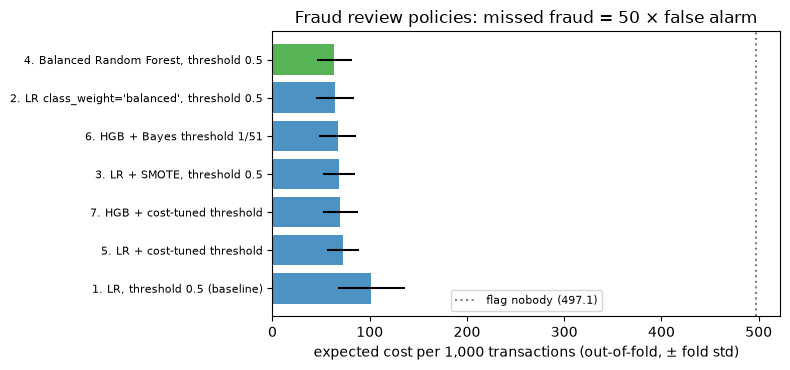

In [53]:
project = pd.DataFrame(oof_rows).T.sort_values("CV cost / 1k")
print(project.round(3).to_string())
chosen_name = project.index[0]
runner_up = project.index[1]
print(f"\nflag nobody: {flag_nobody_cost:.2f} per 1,000 | chosen: {chosen_name} ({project.loc[chosen_name, 'CV cost / 1k']:.2f}) | "
      f"runner-up: {runner_up} ({project.loc[runner_up, 'CV cost / 1k']:.2f})")

fig, ax = plt.subplots(figsize=(8, 3.8))
positions = np.arange(len(project))
ax.barh(positions, project["CV cost / 1k"], xerr=project["fold std"], color=["tab:green"] + ["tab:blue"] * (len(project) - 1), alpha=0.8)
ax.axvline(flag_nobody_cost, ls=":", color="gray", label=f"flag nobody ({flag_nobody_cost:.1f})")
ax.set_yticks(positions, project.index, fontsize=8)
ax.invert_yaxis()
ax.set(xlabel="expected cost per 1,000 transactions (out-of-fold, ± fold std)", title="Fraud review policies: missed fraud = 50 × false alarm")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Step 4 — The one and only test evaluation, with bootstrap confidence intervals

In [54]:
final_model = project_strategies[chosen_name]().fit(fraud_X_dev, fraud_y_dev)
test_decisions = final_model.predict(fraud_X_test)
test_probabilities = final_model.predict_proba(fraud_X_test)[:, 1]
test_report = {
    "cost / 1k": cost_per_1000(fraud_y_test, test_decisions),
    "average precision": average_precision_score(fraud_y_test, test_probabilities),
    "recall": recall_score(fraud_y_test, test_decisions),
    "precision": precision_score(fraud_y_test, test_decisions, zero_division=0.0),
}
intervals = {
    "cost / 1k": bootstrap_ci(fraud_y_test, test_decisions, cost_per_1000),
    "average precision": bootstrap_ci(fraud_y_test, test_probabilities, average_precision_score),
    "recall": bootstrap_ci(fraud_y_test, test_decisions, recall_score),
    "precision": bootstrap_ci(fraud_y_test, test_decisions, lambda y, p: precision_score(y, p, zero_division=0.0)),
}
threshold_used = getattr(final_model, "best_threshold_", getattr(final_model, "threshold", 0.5))
tn, fp, fn, tp = confusion_matrix(fraud_y_test, test_decisions).ravel()
print(f"chosen strategy: {chosen_name} | decision threshold {threshold_used:.4f}")
print(f"test confusion matrix: TP {tp}, FN {fn}, FP {fp}, TN {tn:,}")
for metric, value in test_report.items():
    low, high = intervals[metric]
    print(f"  {metric:18s} {value:7.3f}   95% bootstrap CI [{low:.3f}, {high:.3f}]")

chosen strategy: 4. Balanced Random Forest, threshold 0.5 | decision threshold 0.5000
test confusion matrix: TP 105, FN 18, FP 97, TN 12,153
  cost / 1k           80.579   95% bootstrap CI [48.574, 116.710]
  average precision    0.847   95% bootstrap CI [0.787, 0.901]
  recall               0.854   95% bootstrap CI [0.792, 0.913]
  precision            0.520   95% bootstrap CI [0.457, 0.590]


### Step 5 — Conclusions (computed)

In [55]:
baseline_cv = project.loc["1. LR, threshold 0.5 (baseline)", "CV cost / 1k"]
resampling_names = ["2. LR class_weight='balanced', threshold 0.5", "3. LR + SMOTE, threshold 0.5", "4. Balanced Random Forest, threshold 0.5"]
threshold_names = ["5. LR + cost-tuned threshold", "6. HGB + Bayes threshold 1/51", "7. HGB + cost-tuned threshold"]
best_rebalanced = project.loc[resampling_names, "CV cost / 1k"].idxmin()
best_thresholded = project.loc[threshold_names, "CV cost / 1k"].idxmin()
low, high = intervals["cost / 1k"]
print(f"1. Chosen by CV: {chosen_name}. CV cost {project.loc[chosen_name, 'CV cost / 1k']:.2f} per 1,000 vs baseline {baseline_cv:.2f} "
      f"({1 - project.loc[chosen_name, 'CV cost / 1k'] / baseline_cv:.0%} cheaper) and {flag_nobody_cost:.2f} for flagging nobody.")
print(f"2. Best re-weighting/resampling strategy: {best_rebalanced} ({project.loc[best_rebalanced, 'CV cost / 1k']:.2f}); "
      f"best threshold strategy: {best_thresholded} ({project.loc[best_thresholded, 'CV cost / 1k']:.2f}) → "
      f"{'moving the threshold beat rebalancing the data' if project.loc[best_thresholded, 'CV cost / 1k'] < project.loc[best_rebalanced, 'CV cost / 1k'] else 'rebalancing beat threshold tuning here'}.")
print(f"3. Test cost {test_report['cost / 1k']:.2f} per 1,000 [95% CI {low:.2f}–{high:.2f}]; the CV estimate {project.loc[chosen_name, 'CV cost / 1k']:.2f} "
      f"{'lies inside' if low <= project.loc[chosen_name, 'CV cost / 1k'] <= high else 'lies outside'} that interval.")
print(f"4. At threshold {threshold_used:.4f} the policy catches {test_report['recall']:.0%} of test frauds and {test_report['precision']:.0%} of its alarms are fraud "
      f"({tp + fp} alarms on {len(fraud_y_test):,} payments); test average precision {test_report['average precision']:.3f}.")
print(f"5. Uncertainty is large: with {fraud_y_test.sum()} test frauds, each missed fraud moves the cost by {1000 * COST_FN / len(fraud_y_test):.2f} per 1,000, "
      f"so differences between the top strategies ({project.iloc[1]['CV cost / 1k'] - project.iloc[0]['CV cost / 1k']:.2f} per 1,000 in CV) need more data or repeated CV to settle.")

1. Chosen by CV: 4. Balanced Random Forest, threshold 0.5. CV cost 63.55 per 1,000 vs baseline 101.54 (37% cheaper) and 497.05 for flagging nobody.
2. Best re-weighting/resampling strategy: 4. Balanced Random Forest, threshold 0.5 (63.55); best threshold strategy: 6. HGB + Bayes threshold 1/51 (66.92) → rebalancing beat threshold tuning here.
3. Test cost 80.58 per 1,000 [95% CI 48.57–116.71]; the CV estimate 63.55 lies inside that interval.
4. At threshold 0.5000 the policy catches 85% of test frauds and 52% of its alarms are fraud (202 alarms on 12,373 payments); test average precision 0.847.
5. Uncertainty is large: with 123 test frauds, each missed fraud moves the cost by 4.04 per 1,000, so differences between the top strategies (0.97 per 1,000 in CV) need more data or repeated CV to settle.


**Stretch goals**
1. Add a **review-capacity** constraint (e.g. at most 5 alarms per 1,000 payments) and pick the threshold that minimizes cost subject to it.
2. Make the costs **amount-dependent** (a missed fraud costs its `Amount`): pass `sample_weight`-style costs into the scorer and compare with the flat 50:1 matrix.
3. Re-weight the evaluation to the **true** 0.17% fraud rate (weight each legitimate payment by the subsampling factor) and recompute costs, precision and the optimal threshold.
4. Compare the top two strategies with a paired bootstrap of the test cost difference and with McNemar's test.

### 🗣️ How to talk about this in an interview
- "I started from the decision: a missed fraud costs about 50 false alarms, so the metric is expected cost per 1,000 payments, not accuracy or even F1."
- "I compared seven policies with the same stratified folds: class weights, SMOTE inside the pipeline, a balanced random forest, the Bayes threshold 1/51 and thresholds tuned by internal CV; threshold tuning happened only inside training folds."
- "The test set was used once, for the chosen policy, with bootstrap confidence intervals, because 123 frauds make every metric noisy."
- "The top policies — a balanced random forest, class-weighted logistic regression and gradient boosting at the Bayes threshold 1/51 — were within a fraction of a fold standard deviation. I picked by the rule I'd written down, but I'd confirm with repeated CV or a later time window, and I'd point out that the balanced forest's scores are not calibrated probabilities."
- "In production I'd monitor the fraud rate and the alarm rate, re-tune the threshold when prevalence or costs shift, and use time-based splits because fraud patterns drift."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Your model is 99% accurate on a dataset with 1% positives. Is it good?**

<details><summary>Show answer</summary>

- **30-second answer:** Unknown — predicting "negative" for everyone is also 99% accurate. Look at the confusion matrix, recall and precision on the positive class, a threshold-free metric like average precision against its prevalence baseline, and the business cost of each error.
- **Go deeper:** On our fraud sample the dummy scored 99.0% accuracy and caught zero frauds. Balanced accuracy, MCC, F1 and PR-AUC all expose it. Also check calibration if probabilities are used and evaluate at the prevalence you'll see in production.
- **❌ Common wrong answer:** "Yes, 99% is excellent."

</details>

**Q2. Precision vs recall: how do you decide which matters more?**

<details><summary>Show answer</summary>

- **30-second answer:** From the cost of errors. If missing a positive is expensive (cancer, fraud) favour recall; if false alarms are expensive or capacity is limited (manual reviews, spam blocking real mail) favour precision. Make it explicit with a cost matrix, a precision/recall constraint or F-beta.
- **Go deeper:** Precision depends on prevalence, recall doesn't. With costs $C_{FP}, C_{FN}$ and calibrated probabilities the optimal threshold is $C_{FP}/(C_{FP}+C_{FN})$. Capacity constraints become "precision at top-k" or "recall at k alarms per day".
- **❌ Common wrong answer:** "Always maximize F1."

</details>

**Q3. ROC-AUC or PR-AUC for heavily imbalanced data, and why?**

<details><summary>Show answer</summary>

- **30-second answer:** PR-AUC / average precision. ROC's false-positive rate divides by the huge number of negatives, so thousands of false alarms barely move the curve; precision shows them directly, and AP's random baseline is the prevalence rather than 0.5.
- **Go deeper:** On our fraud data, ROC-AUC preferred logistic regression while average precision preferred gradient boosting. ROC-AUC is prevalence-invariant (good for comparing populations) and equals the Mann–Whitney probability; AP changes with prevalence, so report it with its baseline. Use `average_precision_score`, not `auc(recall, precision)` (linear interpolation is optimistic).
- **❌ Common wrong answer:** "ROC-AUC is always the best metric because it's threshold-independent."

</details>

**Q4. What is calibration, and why do class weights or resampling break it? How do you fix it?**

<details><summary>Show answer</summary>

- **30-second answer:** Calibrated means "p = 0.1" events happen 10% of the time. Training at an artificial positive rate (SMOTE, undersampling, class weights) shifts the model's prior, inflating probabilities. Fix with prior correction (multiply the odds by true prior odds / training prior odds) or recalibrate with `CalibratedClassifierCV` on data the model didn't train on.
- **Go deeper:** In Section 7 a 50:50 undersampled logistic regression predicted a mean fraud probability of about 10% for a 1% fraud rate; one line of prior correction brought it close to 1% with unchanged average precision. Sigmoid (Platt) calibration suits small data, isotonic needs more. Check with reliability diagrams, Brier score and log loss.
- **❌ Common wrong answer:** "Probabilities from `predict_proba` are always real probabilities."

</details>

**Q5. How does SMOTE work, and what are its failure modes?**

<details><summary>Show answer</summary>

- **30-second answer:** For a minority point, pick one of its k nearest minority neighbours and create a new point at a random position on the segment between them. Failure modes: it leaks if applied before splitting, adds noise where classes overlap, can't handle categorical features (use SMOTE-NC), needs scaling, distorts probabilities, and often doesn't help strong models.
- **Go deeper:** Variants: Borderline-SMOTE (only near the boundary), ADASYN (more points around hard examples), SMOTE-Tomek / SMOTE-ENN (then clean). It works in feature space, so synthetic points may be unrealistic in high dimensions. We reproduced imbalanced-learn's samples exactly: same neighbour search, same RNG call order.
- **❌ Common wrong answer:** "SMOTE duplicates minority samples" (that's random oversampling) or "it collects more real data."

</details>

**Q6. Class weights, resampling, or threshold tuning — which do you reach for first?**

<details><summary>Show answer</summary>

- **30-second answer:** Choose the metric, then tune the threshold on validation data; add class weights if the model under-fits the rare class; treat resampling as a hyperparameter validated in CV, not a default.
- **Go deeper:** Weights and resampling mostly move the operating point (similar to a lower threshold) while damaging calibration. In our comparisons the best resampled and non-resampled strategies were usually within fold noise of each other, sometimes one ahead and sometimes the other — so validate on your own data. Undersampling remains useful for training speed on huge datasets; balanced ensembles are strong quick baselines.
- **❌ Common wrong answer:** "Always balance the classes to 50:50 before training."

</details>

**Q7. Macro, micro or weighted averaging for multiclass metrics?**

<details><summary>Show answer</summary>

- **30-second answer:** Macro gives each class equal weight (good when rare classes matter), weighted weights by support (dominated by frequent classes), micro pools all decisions (equals accuracy for single-label multiclass).
- **Go deeper:** On red-wine grades, weighted F1 looked respectable while macro F1 revealed rare grades were never predicted. Always show the per-class report; binary metrics on a multiclass target raise an error unless you choose `average`.
- **❌ Common wrong answer:** "Micro-averaged F1 handles imbalance better."

</details>

**Q8. Why nested cross-validation?**

<details><summary>Show answer</summary>

- **30-second answer:** The best score from a hyperparameter search is optimistically biased because you selected the configuration that happened to score highest on those folds. Nested CV evaluates the whole "search + fit" procedure on outer folds the search never saw.
- **Go deeper:** The bias grows with the number of configurations and shrinks with more data. Use `cross_val_score(GridSearchCV(...), X, y, cv=outer)`. It estimates the performance of the *procedure*; to deploy, run the search once on all training data.
- **❌ Common wrong answer:** "`GridSearchCV.best_score_` is an unbiased estimate of test performance."

</details>

**Q9. How do you tell whether model B is really better than model A?**

<details><summary>Show answer</summary>

- **30-second answer:** Same splits for both, compare paired per-fold differences with a corrected resampled t-test (Nadeau–Bengio), or on a single test set use McNemar's test or a paired bootstrap; report confidence intervals and check the difference is practically meaningful.
- **Go deeper:** The naive paired t-test over CV folds is over-confident because training sets overlap; the corrected variance factor is $1/k + n_{test}/n_{train}$. McNemar only uses the disagreements. With rare positives, intervals are wide: a few frauds change everything.
- **❌ Common wrong answer:** "B's mean CV score is 0.003 higher, so B is better."

</details>

### 💻 Coding

**Q10. Implement average precision in NumPy.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  order = np.argsort(-scores, kind="mergesort")
  y_s, s_s = y[order], scores[order]
  last = np.r_[np.flatnonzero(np.diff(s_s)), len(s_s) - 1]      # group ties
  tp = np.cumsum(y_s)[last]; fp = last + 1 - tp
  precision, recall = tp / (tp + fp), tp / tp[-1]
  ap = np.sum(np.diff(np.r_[0, recall]) * precision)
  ```
- **Go deeper:** Group tied scores into one threshold, don't interpolate (that's the `auc(recall, precision)` mistake), and test against `average_precision_score` — our Build It From Scratch does, including a tie-heavy case.
- **❌ Common wrong answer:** Averaging precision at a few fixed recall levels, or ignoring ties.

</details>

**Q11. Write a leak-free cross-validation of SMOTE + logistic regression.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  from imblearn.pipeline import make_pipeline
  pipe = make_pipeline(StandardScaler(), SMOTE(random_state=0), LogisticRegression(max_iter=5000))
  scores = cross_val_score(pipe, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=0), scoring="average_precision")
  ```
- **Go deeper:** imbalanced-learn's `Pipeline` resamples only in `fit`, so validation folds keep their natural class ratio. Scaling goes before SMOTE (distances). Resampling before `train_test_split` inflated our mammography AP from about 0.5 to above 0.9.
- **❌ Common wrong answer:** `X_res, y_res = SMOTE().fit_resample(X, y)` followed by `cross_val_score(model, X_res, y_res)`.

</details>

### 🐛 Debugging Scenarios

**Q12. Offline precision was 90% on a balanced test set, but in production only 20% of alerts are real. What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Precision depends on prevalence. A test set with 50% positives hides how many false alarms the huge real negative population produces. Recompute precision at the production base rate (or evaluate on a naturally distributed sample) and re-tune the threshold.
- **Go deeper:** Precision = TPR·π / (TPR·π + FPR·(1−π)). With TPR 0.9, FPR 0.1: π = 0.5 gives 0.90, π = 0.03 gives about 0.22. Our prevalence experiment showed precision at a fixed threshold changing a lot while ROC-AUC stayed put. Also check drift and calibration.
- **❌ Common wrong answer:** "The model degraded in production; retrain it."

</details>

**Q13. After adding SMOTE, recall went up but the risk scores sent to the pricing team are now far too high. Why, and what do you do?**

<details><summary>Show answer</summary>

- **30-second answer:** The model learned at an artificial ~50% positive rate, so its probabilities are inflated. Apply prior correction or recalibrate (`CalibratedClassifierCV` with a frozen model on untouched data), or drop SMOTE and tune the threshold instead.
- **Go deeper:** Verify with a reliability diagram and Brier score; keep separate outputs for ranking/decisions and calibrated probabilities; document the training prevalence with the model.
- **❌ Common wrong answer:** "Divide all scores by 2."

</details>

### 🏗️ Design

**Q14. Design the evaluation and decision system for a real-time card-fraud model.**

<details><summary>Show answer</summary>

- **30-second answer:** Define costs (fraud loss vs friction) and review capacity; train on time-ordered data with labels matured for chargeback delays; evaluate on a later time window at natural prevalence with PR-AUC, cost and recall at the operating point, bootstrap CIs; choose thresholds (possibly per segment or amount) on validation data; calibrate scores; monitor alert rate, precision, fraud rate and drift; re-tune thresholds as prevalence shifts.
- **Go deeper:** Group splits by card/customer to avoid leakage; amount-weighted costs; tiered actions (allow, step-up authentication, block) with different thresholds; delayed and biased labels (only reviewed cases get labels — use holdout traffic); shadow deployment and A/B tests; latency budget; adversarial adaptation.
- **❌ Common wrong answer:** "Random 80/20 split, maximize accuracy, threshold 0.5."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** `average_precision_score([0, 0, 1, 1], [0.1, 0.4, 0.35, 0.8])`
<details><summary>Answer</summary>

**0.8333** — ranking by score: 0.8 (pos, P = 1 at R = 0.5), 0.4 (neg), 0.35 (pos, P = 2/3 at R = 1). AP = 0.5·1 + 0.5·(2/3).
</details>

**2.** `roc_auc_score([0, 0, 1, 1], [0.1, 0.4, 0.35, 0.8])`
<details><summary>Answer</summary>

**0.75** — of the 4 positive–negative pairs, 3 are ranked correctly (only 0.35 < 0.4 is wrong).
</details>

**3.** `balanced_accuracy_score([0] * 99 + [1], [0] * 100)`
<details><summary>Answer</summary>

**0.5** — recall on class 1 is 0 and on class 0 is 1; their mean is 0.5, although accuracy is 0.99.
</details>

**4.** `matthews_corrcoef([1, 1, 0, 0], [1, 1, 1, 1])`
<details><summary>Answer</summary>

**0.0** — a constant prediction carries no information; MCC defines the 0/0 case as 0.
</details>

**5.** With calibrated probabilities, a missed positive costs 9 and a false alarm costs 1. Above which probability should you flag?
<details><summary>Answer</summary>

**0.1** — flag when $9p > 1 \cdot (1 - p)$, i.e. $p > 1/(1+9)$.
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html) — every classification, ranking, probability and regression metric used here
- [scikit-learn — Tuning the decision threshold for class prediction](https://scikit-learn.org/stable/modules/classification_threshold.html) · [Post-tuning the decision threshold for cost-sensitive learning](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cost_sensitive_learning.html) — `TunedThresholdClassifierCV` and a credit-card cost example
- [scikit-learn — Probability calibration](https://scikit-learn.org/stable/modules/calibration.html) — reliability diagrams, sigmoid vs isotonic
- [scikit-learn — Nested versus non-nested cross-validation](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html)
- [imbalanced-learn documentation](https://imbalanced-learn.org/stable/) · [Over-sampling](https://imbalanced-learn.org/stable/over_sampling.html) · [Common pitfalls and recommended practices](https://imbalanced-learn.org/stable/common_pitfalls.html) — samplers, pipelines and the data-leakage warning
- [statsmodels — mcnemar](https://www.statsmodels.org/stable/generated/statsmodels.stats.contingency_tables.mcnemar.html)

### 🎥 Videos
- [StatQuest (Josh Starmer) — Machine Learning Fundamentals: The Confusion Matrix](https://www.youtube.com/watch?v=Kdsp6soqA7o) (~7 min) · [Sensitivity and Specificity](https://www.youtube.com/watch?v=vP06aMoz4v8) (~12 min) — the vocabulary of Sections 1–2
- [StatQuest (Josh Starmer) — ROC and AUC, Clearly Explained!](https://www.youtube.com/watch?v=4jRBRDbJemM) (~16 min) — how the ROC curve is built from many confusion matrices, and where precision–recall fits in (Section 3)
- [Guillaume Lemaitre — Get the best from your scikit-learn classifier | PyData Global 2023](https://www.youtube.com/watch?v=Po7PRIBjRoQ) (~28 min) — an imbalanced-learn and scikit-learn maintainer on thresholds, calibration and why resampling is rarely the answer (Sections 6–11)
- [Andreas Müller — Applied ML 2020 - 10 - Calibration, Imbalanced data](https://www.youtube.com/watch?v=w3OPq0V8fr8) (~76 min) — a full lecture covering calibration, resampling and cost-sensitive learning

### 📄 Papers
- [Chawla, Bowyer, Hall & Kegelmeyer (2002) — SMOTE: Synthetic Minority Over-sampling Technique](https://arxiv.org/abs/1106.1813)
- [Saito & Rehmsmeier (2015) — The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0118432)
- [Niculescu-Mizil & Caruana (2005) — Predicting Good Probabilities With Supervised Learning (PDF)](https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf)
- [Chicco & Jurman (2020) — The advantages of the Matthews correlation coefficient (MCC) over F1 score and accuracy in binary classification evaluation](https://pmc.ncbi.nlm.nih.gov/articles/PMC6941312/) — the argument behind Section 2's interview angle
- [Elkan (2001) — The Foundations of Cost-Sensitive Learning (PDF)](https://cseweb.ucsd.edu/~elkan/rescale.pdf) — the threshold rule and prior correction used in Sections 6–7
- [Lemaître, Nogueira & Aridas (2017) — Imbalanced-learn: A Python Toolbox to Tackle the Curse of Imbalanced Datasets in Machine Learning (PDF)](https://www.jmlr.org/papers/volume18/16-365/16-365.pdf)

### 📘 Books & Courses
- [Google Machine Learning Crash Course — Classification](https://developers.google.com/machine-learning/crash-course/classification) — thresholds, confusion matrix, ROC/AUC and prediction bias with interactive exercises

### 🏋️ Practice
- [Kaggle — Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — the full 284,807-payment dataset; try the mini project at the true 0.17% fraud rate

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Confusion matrix | counts TP, FP, FN, TN | `confusion_matrix(y, pred).ravel()` → tn, fp, fn, tp |
| Precision / recall / F-beta | alarm quality / coverage / trade-off | TP/(TP+FP), TP/(TP+FN), `fbeta_score(beta=)` |
| Balanced accuracy, MCC, κ | single-number summaries that expose trivial models | `balanced_accuracy_score`, `matthews_corrcoef`, `cohen_kappa_score` |
| ROC-AUC vs PR-AUC | ranking quality; PR focuses on the rare class | `roc_auc_score`; `average_precision_score` (baseline = prevalence) |
| Log loss, Brier, D² Brier | probability quality | `log_loss`, `brier_score_loss`, `d2_brier_score` |
| Multiclass averaging | combine per-class scores | `average="macro" / "weighted" / "micro"` |
| Cost-based threshold | turn scores into decisions | $t^* = C_{FP}/(C_{FP}+C_{FN})$; `TunedThresholdClassifierCV(scoring=make_scorer(...))`, `FixedThresholdClassifier` |
| Calibration | honest probabilities | `CalibratedClassifierCV(method="sigmoid"/"isotonic")`, `calibration_curve`; prior correction of odds |
| Class weights | weight the loss | `class_weight="balanced"`: $w_c = n/(K n_c)$ |
| Resampling | change training rows, inside folds only | `imblearn.pipeline.make_pipeline(..., RandomUnderSampler / SMOTE / SMOTENC / ADASYN, model)` |
| Cleaning & balanced ensembles | edit the boundary / resample per learner | `TomekLinks`, `EditedNearestNeighbours`, `BalancedRandomForestClassifier`, `EasyEnsembleClassifier` |
| Evaluation protocol | honest estimates | `StratifiedKFold`, `StratifiedGroupKFold`, `TimeSeriesSplit`, nested `GridSearchCV`, bootstrap CIs, corrected t-test, `mcnemar` |

## ➡️ What's Next

**[18 · Model Interpretability: SHAP and LIME](18_Model_Interpretability_SHAP_LIME.ipynb)** — you can now tell whether a model is good and choose how it acts; next you'll open it up and explain *why* it flags a particular transaction, with permutation importance, SHAP values and LIME, and learn which explanations to trust.